# LGBM Temperature Prediction

Train a LightGBM model from the object timeline CSV. This notebook predicts each machine object's future temperature and uses nearby people as context features.


In [1]:
# load project paths and local modules.
from pathlib import Path
from types import SimpleNamespace
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from lgbm_temperature import build_lgbm_dataset, run_lgbm_temperature_pipeline
from visualize_lgbm import (
    build_daily_prediction_gifs,
    plot_feature_importance,
    plot_people_impact_metrics,
)




## Configuration

The input is produced by `06_generation.ipynb`: `tmp/timeline/object_timeline_temperature.csv`.

This notebook compares two single-horizon LGBM models together: one predicts about 5 minutes ahead and the other predicts about 10 minutes ahead. The history window is controlled in `src/lgbm_temperature.py`; it currently uses up to 30 previous observations per object.


In [2]:
# define prediction target settings and output paths.
TEMPERATURE_COLUMN = 'temp_mean_c'
TARGET_MINUTES_LIST = [5.0, 10.0]
TARGET_HORIZON = 1  # used only when target_minutes is none.
PEOPLE_OR_MACHINE = 'machine'

# TRAIN_DATES = ['2025-04-23', '2025-04-24', '2025-04-25', '2025-04-29', '2025-04-30', '2025-05-01']
# VALID_DATES = ['2025-05-02']
# TEST_DATES = ['2025-05-06', '2025-05-07']

TRAIN_DATES = ['2025-04-23', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-06','2025-05-07']
VALID_DATES = ['2025-04-25']
TEST_DATES = [ '2025-04-24', '2025-05-02', ]

VALID_RATIO = 0.15  # used only when date lists are empty.
TEST_RATIO = 0.15   # used only when date lists are empty.
RANDOM_STATE = 42

# set true after running 08 and confirming the tuned parameters improve validation/test behavior.
USE_TUNED_PARAMS = True
TUNED_PARAMS_JSON = config.LGBM_OUTPUT_DIR / 'tuning' / 'best_lgbm_params.json'


# format a prediction horizon for output folder names.
def horizon_tag(target_minutes):
    return f"{int(target_minutes):02d}min" if float(target_minutes).is_integer() else f"{target_minutes:g}min".replace('.', 'p')


# load tuned LGBM parameters from the tuning JSON file.
def load_tuned_params(path):
    if not path.exists():
        raise FileNotFoundError(f'Tuned params JSON not found. Run notebook 08 first: {path}')
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


tuned_params_by_horizon = load_tuned_params(TUNED_PARAMS_JSON) if USE_TUNED_PARAMS else {}


# return tuned LGBM parameters for one horizon when enabled.
def get_model_params(target_minutes):
    if not USE_TUNED_PARAMS:
        return None
    tag = horizon_tag(target_minutes)
    if tag not in tuned_params_by_horizon:
        raise KeyError(f'Missing tuned params for {tag} in {TUNED_PARAMS_JSON}')
    return tuned_params_by_horizon[tag]


# build LGBM pipeline arguments for one prediction horizon.
def make_lgbm_args(target_minutes):
    base_dir = config.LGBM_HORIZON_COMPARE_DIR
    if USE_TUNED_PARAMS:
        base_dir = base_dir / 'tuned'
    output_dir = base_dir / horizon_tag(target_minutes)
    return SimpleNamespace(
        input_csv=config.OBJECT_TIMELINE_CSV,
        prediction_csv=output_dir / 'lgbm_temperature_predictions.csv',
        feature_importance_csv=output_dir / 'lgbm_feature_importance.csv',
        metrics_csv=output_dir / 'lgbm_metrics.csv',
        people_impact_csv=output_dir / 'lgbm_people_impact_metrics.csv',
        learning_curve_png=output_dir / 'lgbm_learning_curve.png',
        model_path=output_dir / 'lgbm_temperature_model.txt',
        temperature_column=TEMPERATURE_COLUMN,
        target_horizon=TARGET_HORIZON,
        target_minutes=target_minutes,
        people_or_machine=PEOPLE_OR_MACHINE,
        train_dates=TRAIN_DATES,
        valid_dates=VALID_DATES,
        test_dates=TEST_DATES,
        valid_ratio=VALID_RATIO,
        test_ratio=TEST_RATIO,
        random_state=RANDOM_STATE,
        model_params=get_model_params(target_minutes),
    )


lgbm_args_by_horizon = {target_minutes: make_lgbm_args(target_minutes) for target_minutes in TARGET_MINUTES_LIST}

{
    'use_tuned_params': USE_TUNED_PARAMS,
    'tuned_params_json': str(TUNED_PARAMS_JSON),
    'output_dirs': {horizon_tag(target_minutes): str(args.prediction_csv.parent) for target_minutes, args in lgbm_args_by_horizon.items()},
    'model_params': {horizon_tag(target_minutes): args.model_params for target_minutes, args in lgbm_args_by_horizon.items()},
}


{'use_tuned_params': True,
 'tuned_params_json': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/tuning/best_lgbm_params.json',
 'output_dirs': {'05min': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min',
  '10min': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/10min'},
 'model_params': {'05min': {'subsample': 0.85,
   'subsample_freq': 1,
   'colsample_bytree': 0.85,
   'reg_alpha': 0.0,
   'min_split_gain': 0.0,
   'num_leaves': 79,
   'max_depth': 10,
   'learning_rate': 0.04767900838150994,
   'min_child_samples': 199,
   'reg_lambda': 0.00020116039695574183,
   'n_estimators': 2000},
  '10min': {'subsample': 0.85,
   'subsample_freq': 1,
   'colsample_bytree': 0.85,
   'reg_alpha': 0.0,
   'min_split_gain': 0.0,
   'num_leaves': 16,
   'max_depth': 6,
   'learning_rate': 0.04178930249466568,
   'min_child_samples': 168,
   'reg_lambda': 0.000460663602

## Build Features Preview


In [3]:
# build model-ready data previews for each horizon.
model_preview_by_horizon = {}
feature_columns_by_horizon = {}
summary_rows = []

for target_minutes, args in lgbm_args_by_horizon.items():
    preview_df, preview_features = build_lgbm_dataset(
        timeline_csv=args.input_csv,
        temperature_column=args.temperature_column,
        target_horizon=args.target_horizon,
        target_minutes=args.target_minutes,
        people_or_machine=args.people_or_machine,
    )
    model_preview_by_horizon[target_minutes] = preview_df
    feature_columns_by_horizon[target_minutes] = preview_features
    summary_rows.append({
        'target_minutes': target_minutes,
        'rows': len(preview_df),
        'objects': preview_df['object_id'].nunique(),
        'start': preview_df['timestamp_dt'].min(),
        'end': preview_df['timestamp_dt'].max(),
        'actual_target_min': preview_df['target_minutes_ahead'].min(),
        'actual_target_median': preview_df['target_minutes_ahead'].median(),
        'actual_target_max': preview_df['target_minutes_ahead'].max(),
        'feature_count': len(preview_features),
    })

model_df = model_preview_by_horizon[TARGET_MINUTES_LIST[0]]
feature_columns = feature_columns_by_horizon[TARGET_MINUTES_LIST[0]]
feature_columns_comparison = pd.DataFrame({
    f'{horizon_tag(target_minutes)}_features': pd.Series(feature_columns_by_horizon[target_minutes])
    for target_minutes in TARGET_MINUTES_LIST
})

display(pd.DataFrame(summary_rows))
display(feature_columns_comparison)




,target_minutes,rows,objects,start,end,actual_target_min,actual_target_median,actual_target_max,feature_count
0,5.0,55249,14,2025-04-23 13:43:32,2025-05-07 15:12:46,5.0,5.0,7.5,60
1,10.0,55027,14,2025-04-23 13:43:32,2025-05-07 15:07:46,10.0,10.0,15.0,60


,05min_features,10min_features
0,object_id,object_id
1,canonical_label,canonical_label
2,display_x,display_x
3,display_y,display_y
4,anchor_x,anchor_x
5,anchor_y,anchor_y
6,hour,hour
7,minute,minute
8,day_of_week,day_of_week
9,source_temp,source_temp


In [4]:
# train and evaluate LGBM temperature prediction.
preview_heads = []
for target_minutes, preview_df in model_preview_by_horizon.items():
    part = preview_df.head(5).copy()
    part.insert(0, 'target_minutes', target_minutes)
    preview_heads.append(part)

pd.concat(preview_heads, ignore_index=True)


,target_minutes,object_id,timestamp_dt,timestamp,canonical_label,clustering_method,static_cluster_id,display_x,display_y,anchor_x,...,temp_roll_std_5,temp_roll_mean_10,temp_roll_std_10,temp_roll_mean_20,temp_roll_std_20,temp_roll_mean_30,temp_roll_std_30,temp_delta_1,seconds_since_previous,target_minutes_ahead
0,5.0,cableduct_1,2025-04-23 13:44:33,2025-04-23 13:44:33,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.130437,21.266367,0.129325,21.286515,0.103309,21.347948,0.137751,-0.014088,31.0,5.483333
1,5.0,cableduct_1,2025-04-23 13:45:02,2025-04-23 13:45:02,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.114328,21.234811,0.143074,21.272432,0.116684,21.324819,0.128784,0.040497,29.0,5.000000
2,5.0,cableduct_1,2025-04-23 13:45:32,2025-04-23 13:45:32,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.044814,21.202159,0.136674,21.254032,0.116573,21.315347,0.136044,-0.033350,30.0,5.016667
3,5.0,cableduct_1,2025-04-23 13:46:02,2025-04-23 13:46:02,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.015343,21.176309,0.139470,21.243323,0.125427,21.296591,0.132881,0.022722,30.0,5.000000
4,5.0,cableduct_1,2025-04-23 13:46:32,2025-04-23 13:46:32,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.016610,21.148159,0.128306,21.237027,0.131007,21.287156,0.138709,-0.005428,30.0,5.000000
5,10.0,cableduct_1,2025-04-23 13:44:33,2025-04-23 13:44:33,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.130437,21.266367,0.129325,21.286515,0.103309,21.347948,0.137751,-0.014088,31.0,10.483333
6,10.0,cableduct_1,2025-04-23 13:45:02,2025-04-23 13:45:02,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.114328,21.234811,0.143074,21.272432,0.116684,21.324819,0.128784,0.040497,29.0,10.000000
7,10.0,cableduct_1,2025-04-23 13:45:32,2025-04-23 13:45:32,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.044814,21.202159,0.136674,21.254032,0.116573,21.315347,0.136044,-0.033350,30.0,10.000000
8,10.0,cableduct_1,2025-04-23 13:46:02,2025-04-23 13:46:02,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.015343,21.176309,0.139470,21.243323,0.125427,21.296591,0.132881,0.022722,30.0,10.000000
9,10.0,cableduct_1,2025-04-23 13:46:32,2025-04-23 13:46:32,Cableduct,dbscan_cableduct,dbscan_cableduct_0001,11.689842,3.324211,11.689842,...,0.016610,21.148159,0.128306,21.237027,0.131007,21.287156,0.138709,-0.005428,30.0,10.000000


## People Context Preview


In [5]:
# train and evaluate LGBM temperature prediction.
people_context_columns = [
    column for column in feature_columns
    if column.startswith('people_') or column.startswith('nearest_person') or column == 'mean_person_distance'
]
model_df[people_context_columns].describe()


,people_count_total,people_count_within_1m,people_count_within_2m,people_count_within_3m,nearest_person_distance,mean_person_distance,nearest_person_dx,nearest_person_dy
count,55249.000000,55249.000000,55249.000000,55249.000000,19337.000000,19337.000000,19337.000000,19337.000000
mean,0.437202,0.019023,0.065630,0.134156,4.045691,4.260858,-0.528510,1.291654
std,0.677195,0.137663,0.255975,0.374816,2.239108,2.194060,3.923536,2.010010
min,0.000000,0.000000,0.000000,0.000000,0.052674,0.052674,-12.005157,-4.963619
25%,0.000000,0.000000,0.000000,0.000000,2.440647,2.725282,-2.947131,0.005923
50%,0.000000,0.000000,0.000000,0.000000,3.804893,4.003305,-0.486515,1.580436
75%,1.000000,0.000000,0.000000,0.000000,5.113787,5.420938,2.152919,2.908797
max,5.000000,2.000000,3.000000,4.000000,12.163578,12.163578,8.628493,4.378191


## Train LGBM and Compare 5 vs 10 Minutes


Training horizon: 5 minutes
Training horizon: 10 minutes


,target_minutes,split,mae,rmse,r2
0,5.0,train,0.277044,0.425386,0.858937
1,5.0,valid,0.417946,0.558779,0.484393
2,5.0,test,0.306516,0.424391,0.748126
3,10.0,train,0.329831,0.491693,0.812364
4,10.0,valid,0.482579,0.619962,0.394549
5,10.0,test,0.334526,0.455355,0.709656


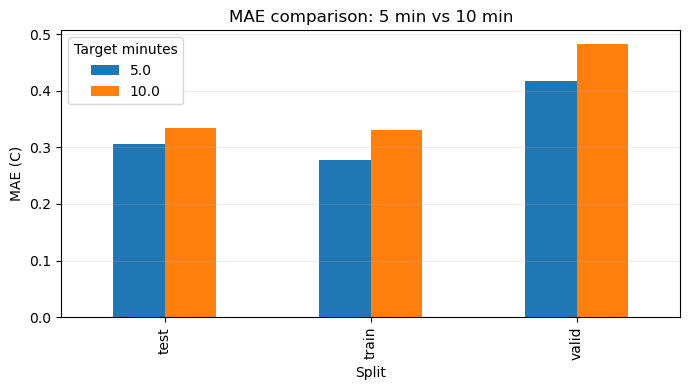

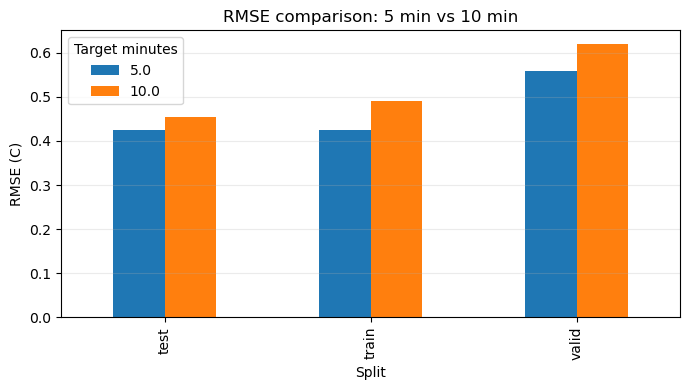

In [6]:
# train models and collect outputs for each horizon.
results_by_horizon = {}
metrics_tables = []

for target_minutes, args in lgbm_args_by_horizon.items():
    print(f"Training horizon: {target_minutes:g} minutes")
    horizon_result = run_lgbm_temperature_pipeline(args)
    results_by_horizon[target_minutes] = horizon_result
    metrics_part = pd.DataFrame(horizon_result['metrics'])
    metrics_part.insert(0, 'target_minutes', target_minutes)
    metrics_tables.append(metrics_part)

metrics_comparison = pd.concat(metrics_tables, ignore_index=True)
display(metrics_comparison)

for metric in ['mae', 'rmse']:
    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = metrics_comparison.pivot(index='split', columns='target_minutes', values=metric)
    plot_df.plot(kind='bar', ax=ax)
    ax.set_title(f'{metric.upper()} comparison: 5 min vs 10 min')
    ax.set_xlabel('Split')
    ax.set_ylabel(f'{metric.upper()} (C)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title='Target minutes')
    fig.tight_layout()


## Learning Curves


{'05min': {'train': OrderedDict([('rmse',
                [1.0889991578769727,
                 1.0478114179951359,
                 1.0092170125046616,
                 0.972777617669513,
                 0.9381300451868768,
                 0.9056479099016145,
                 0.8750001909880369,
                 0.8461131643024289,
                 0.8190837451945466,
                 0.7936331646255049,
                 0.7696882261862917,
                 0.74738714536746,
                 0.7263636582970066,
                 0.7066458514372546,
                 0.6883872210002222,
                 0.6714254982652398,
                 0.6555209936136694,
                 0.6404516378868444,
                 0.6264231114502936,
                 0.6134281559980223,
                 0.6013572871010384,
                 0.5898634407141216,
                 0.5794441610032174,
                 0.5695647971674506,
                 0.5603426535395372,
                 0.5519609221823165,

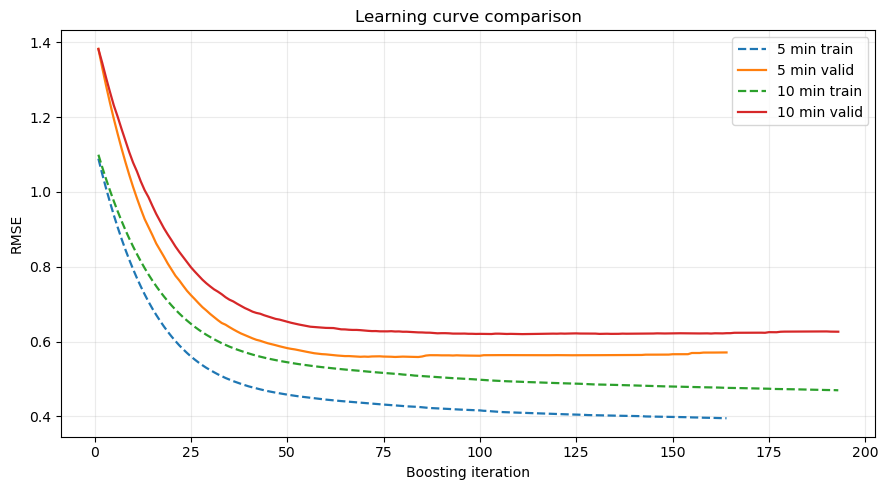

In [7]:
# create a diagnostic plot for the current result table.
fig, ax = plt.subplots(figsize=(9, 5))
for target_minutes, horizon_result in results_by_horizon.items():
    evals = horizon_result['evals_result']
    for split_name, linestyle in [('train', '--'), ('valid', '-')]:
        rmse_values = evals.get(split_name, {}).get('rmse', [])
        if rmse_values:
            ax.plot(
                range(1, len(rmse_values) + 1),
                rmse_values,
                linestyle=linestyle,
                linewidth=1.6,
                label=f'{target_minutes:g} min {split_name}',
            )
ax.set_title('Learning curve comparison')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('RMSE')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

{horizon_tag(target_minutes): horizon_result['evals_result'] for target_minutes, horizon_result in results_by_horizon.items()}


## Outputs


In [8]:
# train and evaluate LGBM temperature prediction.
{
    horizon_tag(target_minutes): {
        'prediction_csv': str(args.prediction_csv),
        'feature_importance_csv': str(args.feature_importance_csv),
        'metrics_csv': str(args.metrics_csv),
        'people_impact_csv': str(args.people_impact_csv),
        'learning_curve_plot': str(args.learning_curve_png),
        'model_path': str(args.model_path),
    }
    for target_minutes, args in lgbm_args_by_horizon.items()
}


{'05min': {'prediction_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_temperature_predictions.csv',
  'feature_importance_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_feature_importance.csv',
  'metrics_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_metrics.csv',
  'people_impact_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_people_impact_metrics.csv',
  'learning_curve_plot': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_learning_curve.png',
  'model_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_temperature_model.txt'},
 '10min': {'prediction_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intersh

## Test-Only Prediction CSVs


In [9]:
# export test-only prediction CSV files.
test_prediction_paths = {}
for target_minutes, args in lgbm_args_by_horizon.items():
    predictions = pd.read_csv(args.prediction_csv)
    test_predictions = predictions[predictions['split'] == 'test'].copy()
    output_csv = args.prediction_csv.with_name('lgbm_temperature_predictions_test.csv')
    test_predictions.to_csv(output_csv, index=False)
    test_prediction_paths[horizon_tag(target_minutes)] = {
        'path': str(output_csv),
        'rows': len(test_predictions),
        'dates': sorted(pd.to_datetime(test_predictions['timestamp']).dt.date.astype(str).unique().tolist()),
    }

test_prediction_paths


{'05min': {'path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/05min/lgbm_temperature_predictions_test.csv',
  'rows': 15350,
  'dates': ['2025-04-24', '2025-05-02']},
 '10min': {'path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/horizon_compare/tuned/10min/lgbm_temperature_predictions_test.csv',
  'rows': 15275,
  'dates': ['2025-04-24', '2025-05-02']}}

## Feature Importance Comparison

Both horizons are shown together. Higher importance means that feature was used more often or more strongly by the trees in that model.


target_minutes,5.0,10.0
feature,,
minute,524.0,127.0
hour,459.0,267.0
source_temp,451.0,178.0
object_id,356.0,159.0
temp_roll_std_30,278.0,91.0
temp_roll_std_20,272.0,65.0
temp_roll_std_10,226.0,19.0
temp_roll_std_5,224.0,37.0
temp_roll_mean_20,213.0,77.0


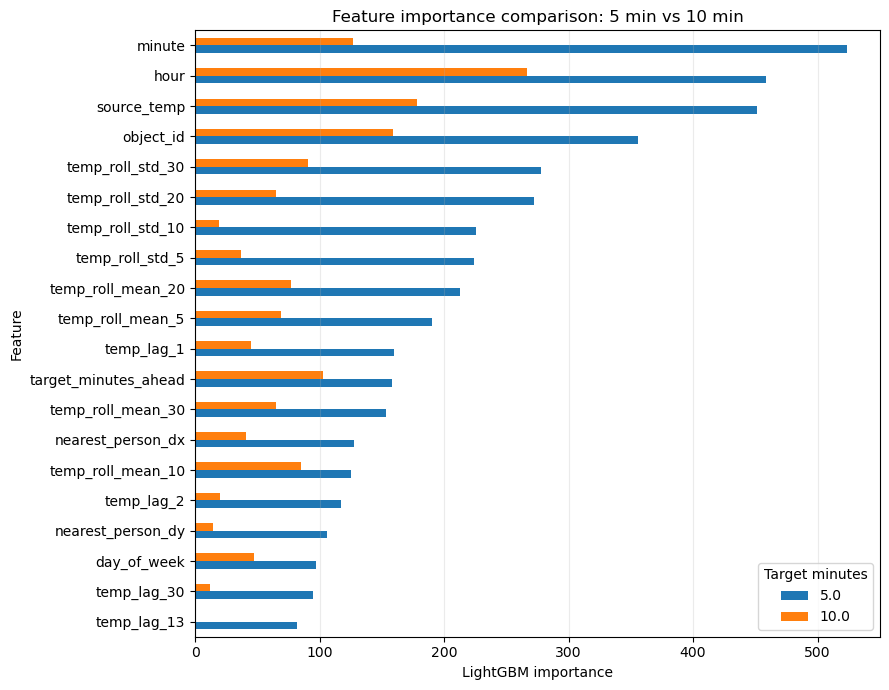

In [10]:
# collect feature importance tables for comparison.
importance_tables = []
for target_minutes, horizon_result in results_by_horizon.items():
    part = horizon_result['feature_importance'].copy()
    part['target_minutes'] = target_minutes
    importance_tables.append(part)

importance_all = pd.concat(importance_tables, ignore_index=True)
importance_pivot = (
    importance_all.pivot_table(index='feature', columns='target_minutes', values='importance', fill_value=0)
    .sort_values(TARGET_MINUTES_LIST[0], ascending=False)
)
display(importance_pivot.head(30))

top_features = importance_pivot.max(axis=1).sort_values(ascending=False).head(20).index
plot_df = importance_pivot.loc[top_features].sort_values(TARGET_MINUTES_LIST[0])
fig, ax = plt.subplots(figsize=(9, 7))
plot_df.plot(kind='barh', ax=ax)
ax.set_title('Feature importance comparison: 5 min vs 10 min')
ax.set_xlabel('LightGBM importance')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()


In [11]:
# train and evaluate LGBM temperature prediction.
importance_all.sort_values(['target_minutes', 'importance'], ascending=[True, False]).groupby('target_minutes').head(25)


,feature,importance,target_minutes
0,minute,524,5.0
1,hour,459,5.0
2,source_temp,451,5.0
3,object_id,356,5.0
4,temp_roll_std_30,278,5.0
5,temp_roll_std_20,272,5.0
6,temp_roll_std_10,226,5.0
7,temp_roll_std_5,224,5.0
8,temp_roll_mean_20,213,5.0
9,temp_roll_mean_5,190,5.0


## People Feature Importance


In [12]:
# train and evaluate LGBM temperature prediction.
people_importance = importance_all.query("feature in @people_context_columns").copy()
people_importance.pivot_table(index='feature', columns='target_minutes', values='importance', fill_value=0)


target_minutes,5.0,10.0
feature,,
mean_person_distance,78.0,15.0
nearest_person_distance,81.0,6.0
nearest_person_dx,128.0,41.0
nearest_person_dy,106.0,14.0
people_count_total,34.0,4.0
people_count_within_1m,0.0,0.0
people_count_within_2m,1.0,0.0
people_count_within_3m,1.0,0.0


## People Impact Error Comparison


,split,people_group,rows,mae,rmse,r2,target_minutes
12,test,all_rows,15350,0.306516,0.424391,0.748126,5.0
13,test,no_person_detected,9776,0.257095,0.357519,0.792191,5.0
14,test,person_detected,5574,0.393195,0.521358,0.649266,5.0
15,test,person_within_1m,238,0.478192,0.607098,0.317635,5.0
16,test,person_within_2m,943,0.433584,0.583927,0.614487,5.0
17,test,person_within_3m,1756,0.408977,0.551675,0.617508,5.0
30,test,all_rows,15275,0.334526,0.455355,0.709656,10.0
31,test,no_person_detected,9735,0.293710,0.394081,0.746215,10.0
32,test,person_detected,5540,0.406249,0.546633,0.624937,10.0
33,test,person_within_1m,233,0.411082,0.530459,0.454284,10.0


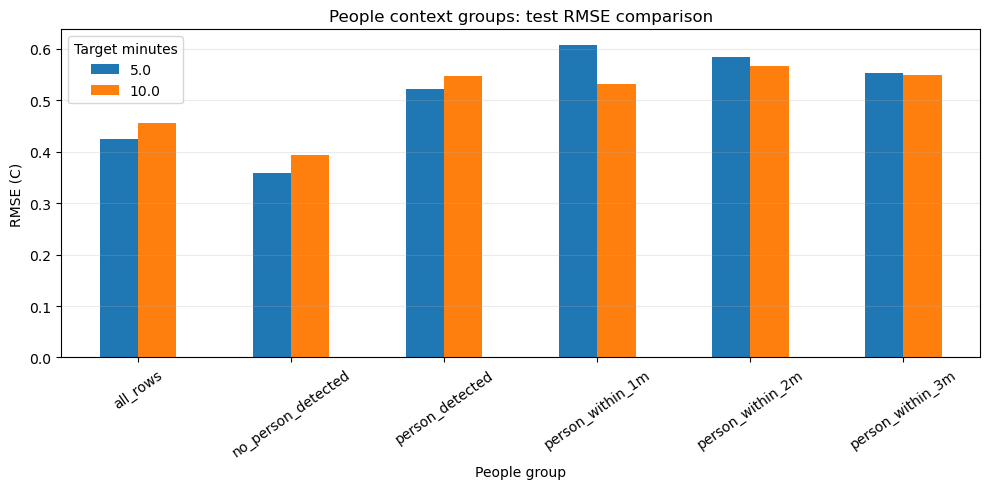

In [13]:
# train and evaluate LGBM temperature prediction.
people_impact_all = []
for target_minutes, horizon_result in results_by_horizon.items():
    part = horizon_result['people_impact'].copy()
    part['target_minutes'] = target_minutes
    people_impact_all.append(part)
people_impact_all = pd.concat(people_impact_all, ignore_index=True)

test_people_impact = people_impact_all.query("split == 'test'").copy()
display(test_people_impact)

plot_df = test_people_impact.pivot(index='people_group', columns='target_minutes', values='rmse')
fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind='bar', ax=ax)
ax.set_title('People context groups: test RMSE comparison')
ax.set_xlabel('People group')
ax.set_ylabel('RMSE (C)')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()


In [14]:
# train and evaluate LGBM temperature prediction.
people_impact_all


,split,people_group,rows,mae,rmse,r2,target_minutes
0,train,all_rows,32475,0.277044,0.425386,0.858937,5.0
1,train,no_person_detected,20648,0.218233,0.350255,0.889047,5.0
2,train,person_detected,11827,0.379718,0.531688,0.780462,5.0
3,train,person_within_1m,711,0.460314,0.632326,0.820968,5.0
4,train,person_within_2m,2140,0.450470,0.627923,0.791105,5.0
5,train,person_within_3m,4186,0.422328,0.585863,0.783230,5.0
6,valid,all_rows,7424,0.417946,0.558779,0.484393,5.0
7,valid,no_person_detected,5488,0.360644,0.489206,0.418279,5.0
8,valid,person_detected,1936,0.580382,0.720359,0.294961,5.0
9,valid,person_within_1m,94,0.547017,0.674871,0.465683,5.0


## Prediction vs Ground Truth with 95% CI

Each horizon gets its own object-level empirical 95% CI, then both horizons are compared together.


In [15]:
# combine test prediction rows across horizons.
test_pred_parts = []
ci_rows = []

for target_minutes, horizon_result in results_by_horizon.items():
    part_pred = horizon_result['predictions'].query("split == 'test'").copy()
    part_pred['target_minutes'] = target_minutes
    part_pred['target_timestamp'] = pd.to_datetime(part_pred['target_timestamp'])
    part_pred['timestamp'] = pd.to_datetime(part_pred['timestamp'])
    part_pred['residual_gt_minus_pred'] = part_pred['target_temp'] - part_pred['prediction']
    part_pred['abs_error'] = part_pred['error'].abs()

    for object_id, object_part in part_pred.groupby('object_id'):
        q025 = object_part['residual_gt_minus_pred'].quantile(0.025)
        q975 = object_part['residual_gt_minus_pred'].quantile(0.975)
        lower = object_part['prediction'] + q025
        upper = object_part['prediction'] + q975
        coverage = ((object_part['target_temp'] >= lower) & (object_part['target_temp'] <= upper)).mean()
        ci_rows.append({
            'target_minutes': target_minutes,
            'object_id': object_id,
            'canonical_label': object_part['canonical_label'].mode().iloc[0] if not object_part['canonical_label'].mode().empty else '',
            'rows': len(object_part),
            'mae': object_part['abs_error'].mean(),
            'rmse': np.sqrt(np.mean(object_part['error'] ** 2)),
            'mean_error': object_part['error'].mean(),
            'residual_q025': q025,
            'residual_q975': q975,
            'ci_width': q975 - q025,
            'coverage': coverage,
        })
    test_pred_parts.append(part_pred)

test_pred = pd.concat(test_pred_parts, ignore_index=True)
ci_metrics = pd.DataFrame(ci_rows).sort_values(['target_minutes', 'ci_width'])
test_pred = test_pred.merge(
    ci_metrics[['target_minutes', 'object_id', 'residual_q025', 'residual_q975', 'ci_width']],
    on=['target_minutes', 'object_id'],
    how='left',
)
test_pred['ci_lower'] = test_pred['prediction'] + test_pred['residual_q025']
test_pred['ci_upper'] = test_pred['prediction'] + test_pred['residual_q975']
ci_metrics


,target_minutes,object_id,canonical_label,rows,mae,rmse,mean_error,residual_q025,residual_q975,ci_width,coverage
7,5.0,machine_3,Machine,253,0.180007,0.224057,0.141151,-0.450471,0.239723,0.690194,0.944664
5,5.0,machine_1,Machine,414,0.233839,0.298040,0.120298,-0.598678,0.489219,1.087898,0.946860
4,5.0,chair_1,Chair,132,0.323413,0.435720,0.087803,-0.605167,0.735907,1.341074,0.939394
8,5.0,machine_4,Machine,789,0.240462,0.329382,0.032661,-0.599520,0.791446,1.390966,0.949303
2,5.0,cableduct_3,Cableduct,1762,0.291539,0.394325,0.022439,-0.627463,0.937699,1.565161,0.948922
12,5.0,window_1,Window,644,0.305200,0.404068,-0.013991,-0.635357,0.984191,1.619548,0.947205
9,5.0,machine_6,Machine,1605,0.293107,0.394997,0.048975,-0.721661,0.924724,1.646385,0.948910
11,5.0,screen_2,Screen,1856,0.272001,0.397035,0.049429,-0.616400,1.054006,1.670406,0.949353
6,5.0,machine_2,Machine,1426,0.276065,0.406287,0.034503,-0.681430,1.058347,1.739778,0.949509
3,5.0,cableduct_4,Cableduct,1831,0.331842,0.457145,0.009497,-0.686995,1.160413,1.847408,0.949754


## Confidence by Object and Horizon


target_minutes,5.0,10.0
object_id,,
machine_3,0.690194,0.781745
machine_1,1.087898,1.387131
chair_1,1.341074,1.399450
machine_4,1.390966,1.525114
window_1,1.619548,1.652618
cableduct_3,1.565161,1.739554
machine_6,1.646385,1.757772
machine_2,1.739778,1.738339
screen_2,1.670406,1.839487


Most confident objects have the narrowest CI width.


,target_minutes,object_id,canonical_label,rows,ci_width,coverage,rmse,mae,mean_error
7,5.0,machine_3,Machine,253,0.690194,0.944664,0.224057,0.180007,0.141151
5,5.0,machine_1,Machine,414,1.087898,0.946860,0.298040,0.233839,0.120298
4,5.0,chair_1,Chair,132,1.341074,0.939394,0.435720,0.323413,0.087803
8,5.0,machine_4,Machine,789,1.390966,0.949303,0.329382,0.240462,0.032661
2,5.0,cableduct_3,Cableduct,1762,1.565161,0.948922,0.394325,0.291539,0.022439
12,5.0,window_1,Window,644,1.619548,0.947205,0.404068,0.305200,-0.013991
9,5.0,machine_6,Machine,1605,1.646385,0.948910,0.394997,0.293107,0.048975
11,5.0,screen_2,Screen,1856,1.670406,0.949353,0.397035,0.272001,0.049429
6,5.0,machine_2,Machine,1426,1.739778,0.949509,0.406287,0.276065,0.034503
3,5.0,cableduct_4,Cableduct,1831,1.847408,0.949754,0.457145,0.331842,0.009497


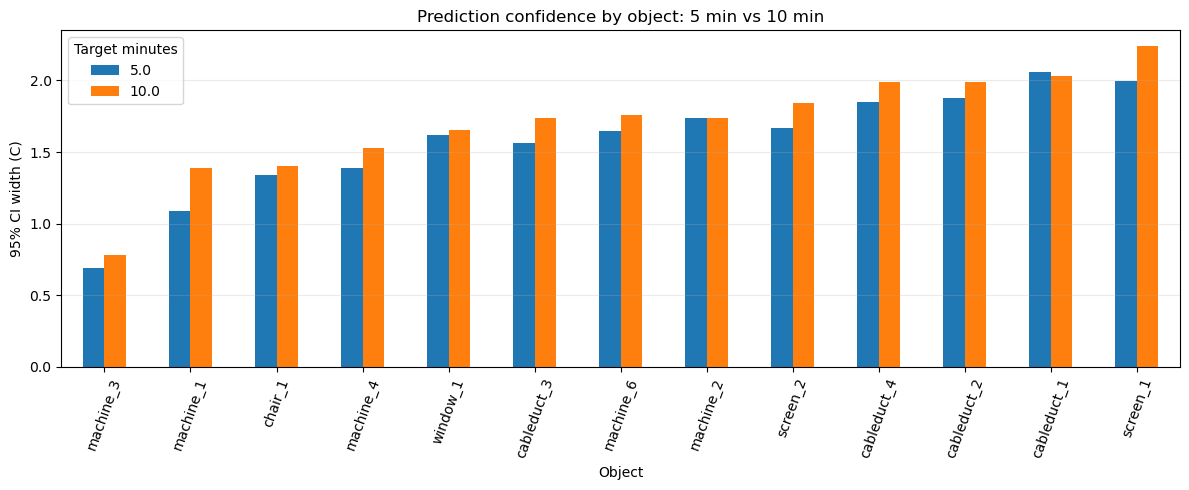

In [16]:
# summarize CI width by object and horizon.
confidence_pivot = ci_metrics.pivot_table(index='object_id', columns='target_minutes', values='ci_width')
confidence_pivot = confidence_pivot.loc[confidence_pivot.mean(axis=1).sort_values().index]
display(confidence_pivot)

fig, ax = plt.subplots(figsize=(12, 5))
confidence_pivot.plot(kind='bar', ax=ax)
ax.set_title('Prediction confidence by object: 5 min vs 10 min')
ax.set_xlabel('Object')
ax.set_ylabel('95% CI width (C)')
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()

print('Most confident objects have the narrowest CI width.')
display(ci_metrics[['target_minutes', 'object_id', 'canonical_label', 'rows', 'ci_width', 'coverage', 'rmse', 'mae', 'mean_error']].head(20))


## Forecast Curves with 95% CI by Day

Each object/date figure uses the clean timeline CSV for ground truth. Prediction rows are aggregated by target timestamp before plotting so repeated source rows do not create duplicate points.



GT plot rows from timeline: 60,334
Prediction plot rows: 30,625 -> 23,978 after target-time aggregation
Target date: 2025-04-24
Target date: 2025-05-02


/var/folders/r7/6cnjjpl12cl8kc68cxt7dd9w0000gn/T/ipykernel_52527/3714148812.py:98: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(13, 4.8))


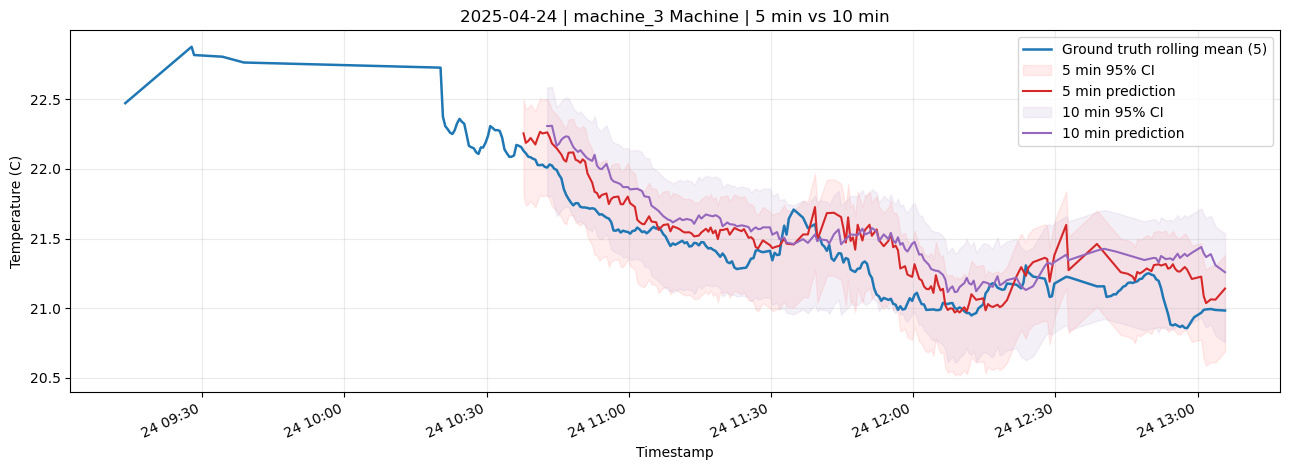

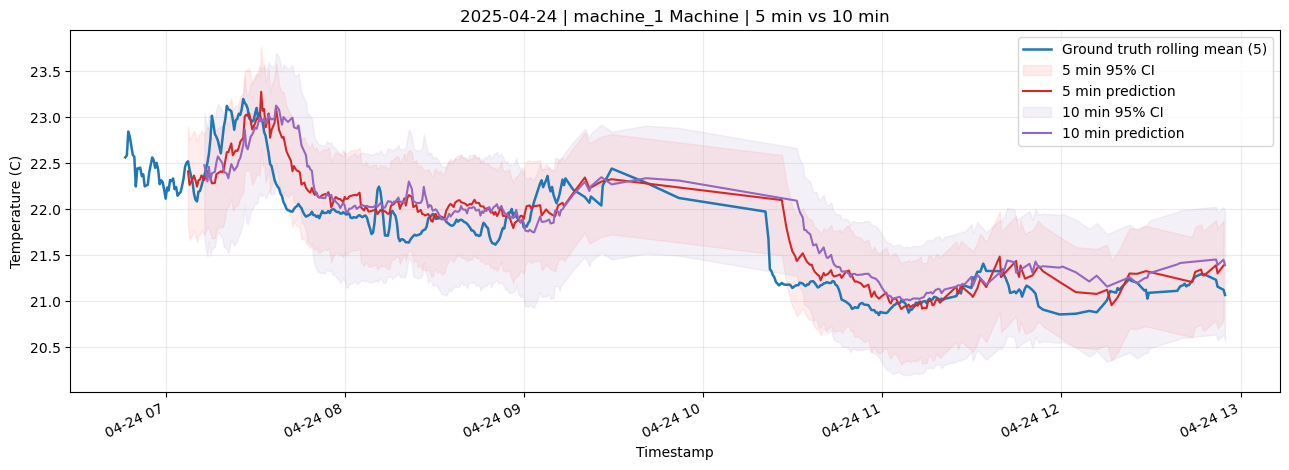

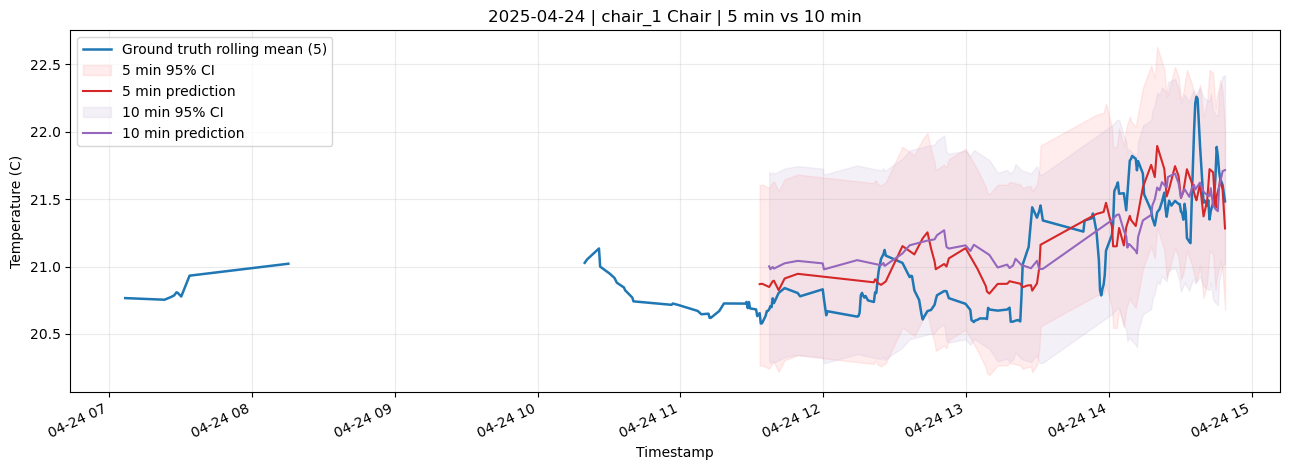

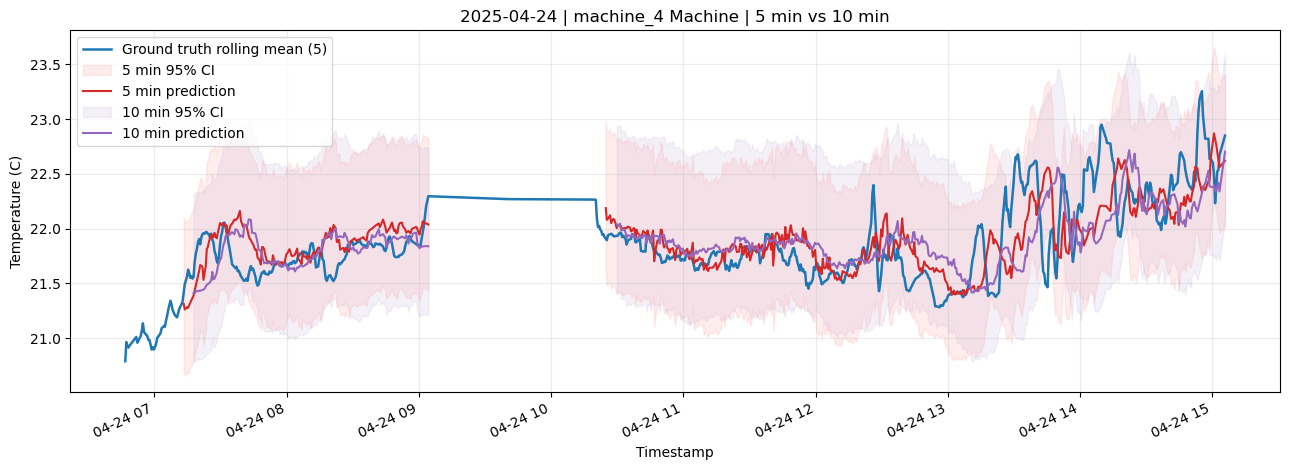

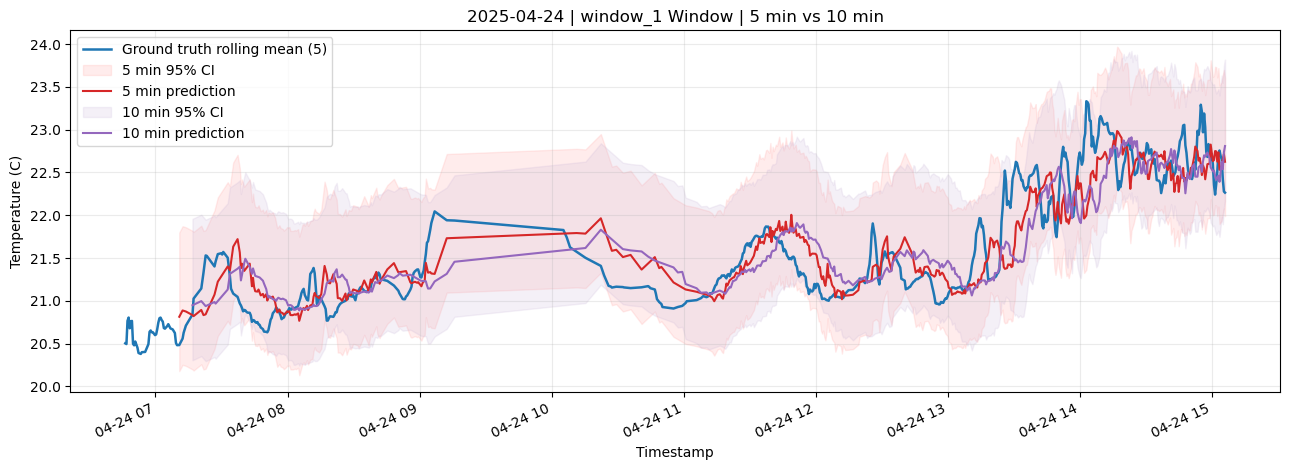

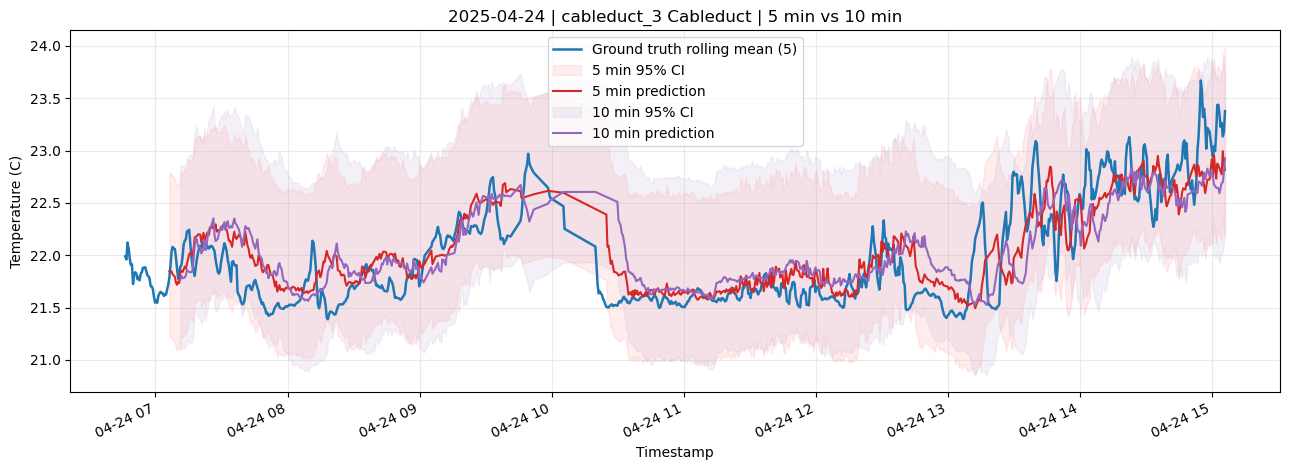

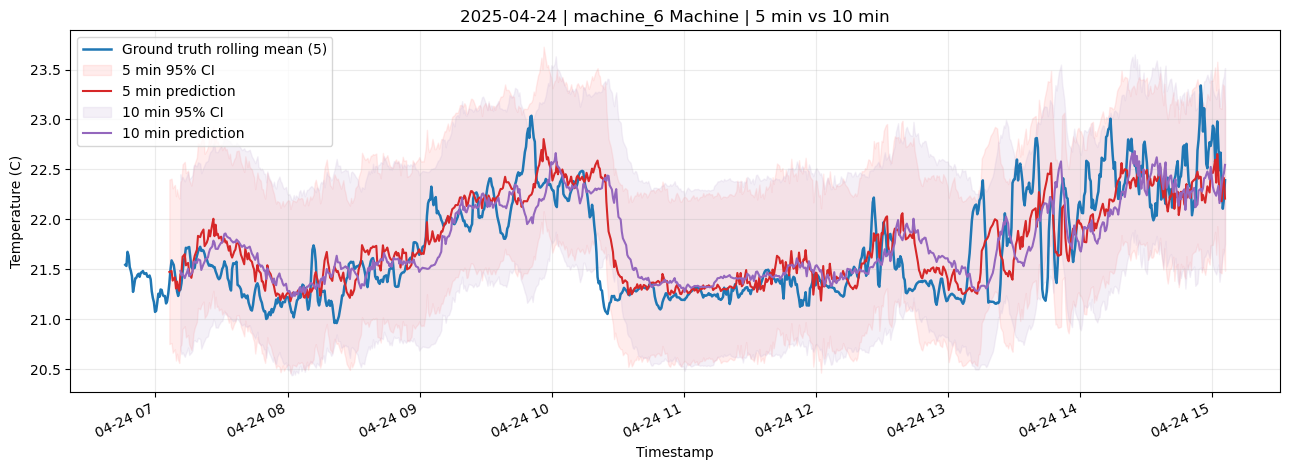

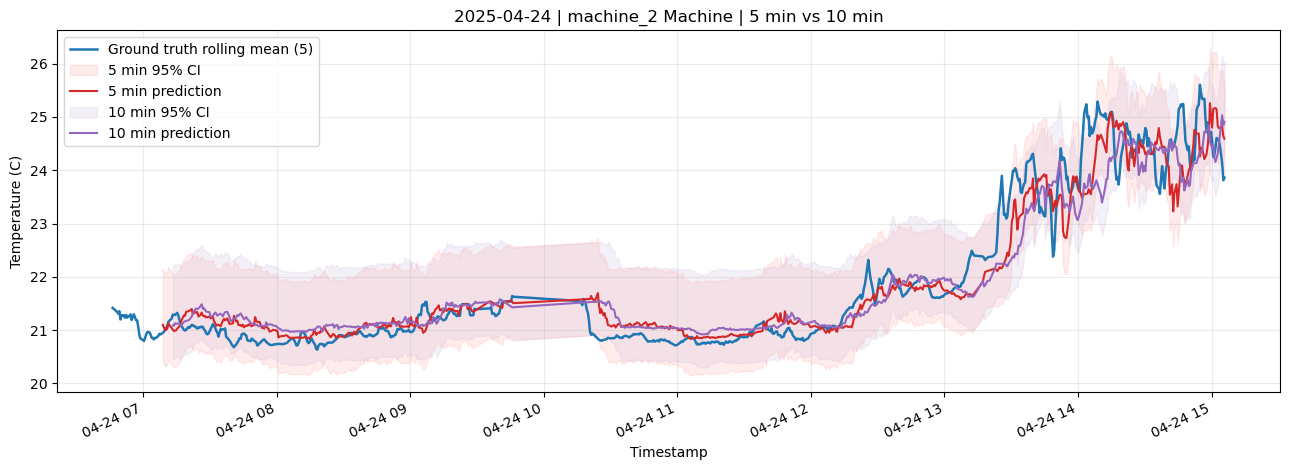

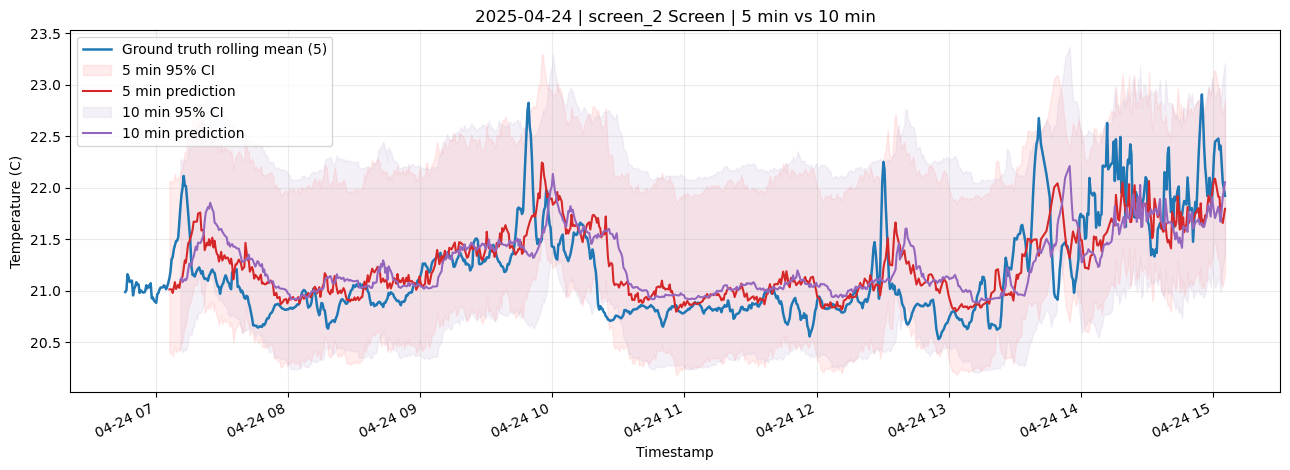

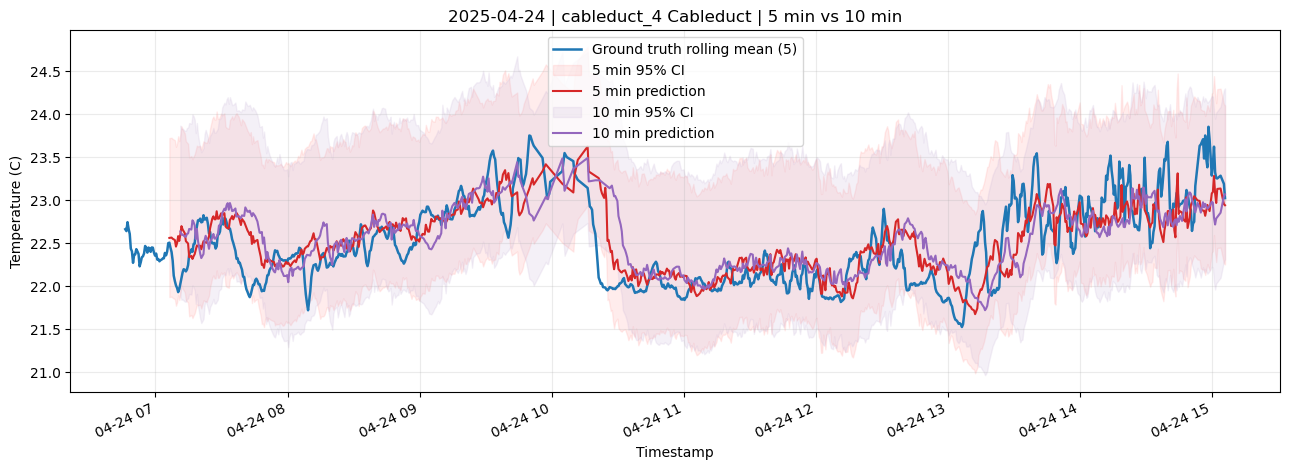

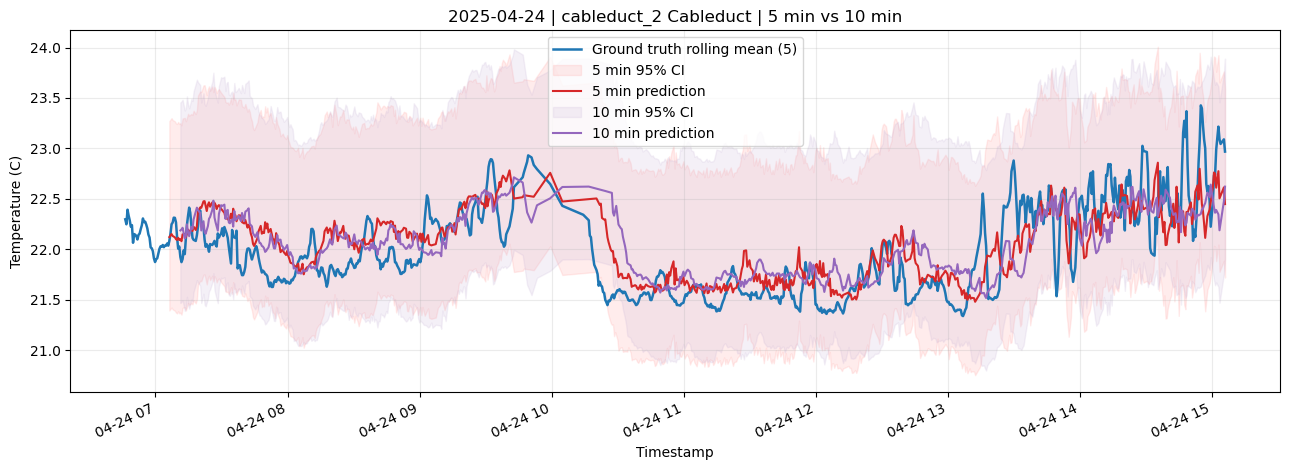

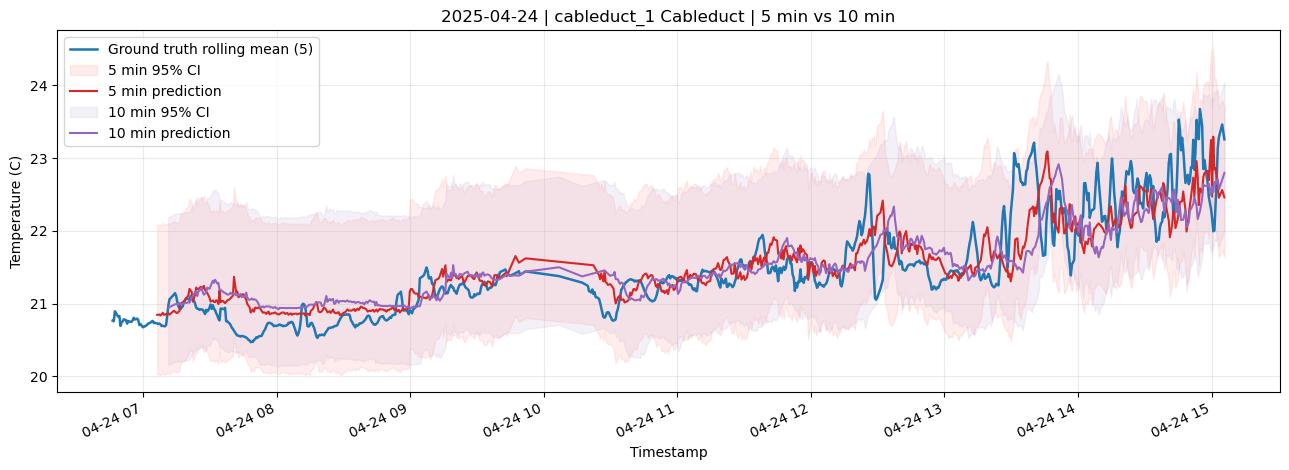

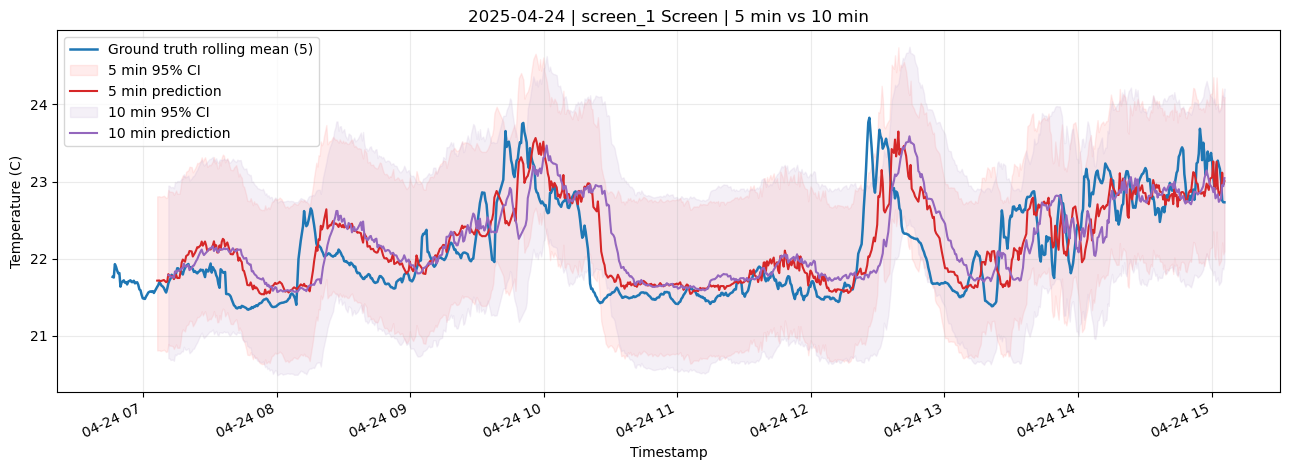

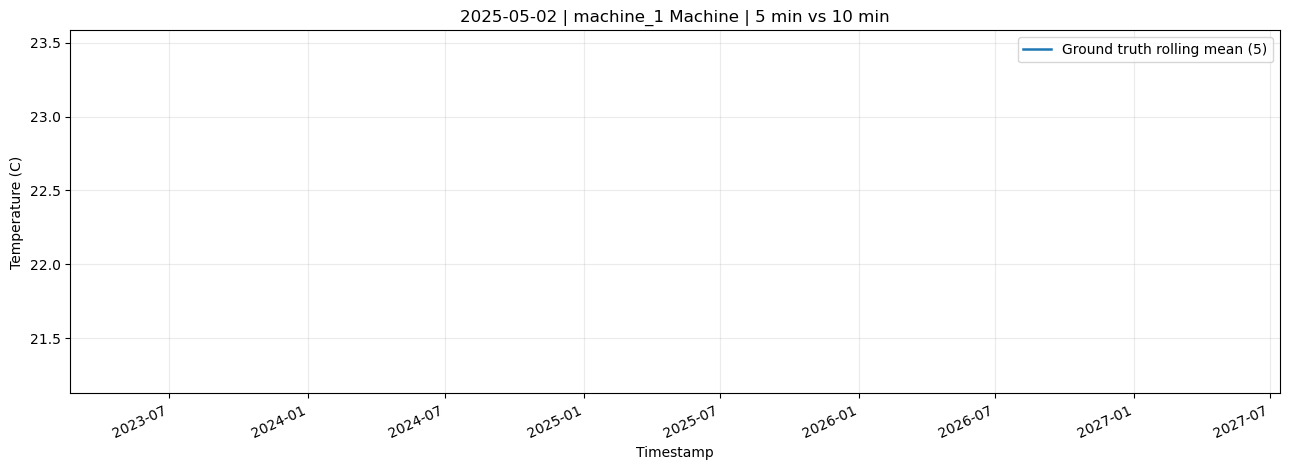

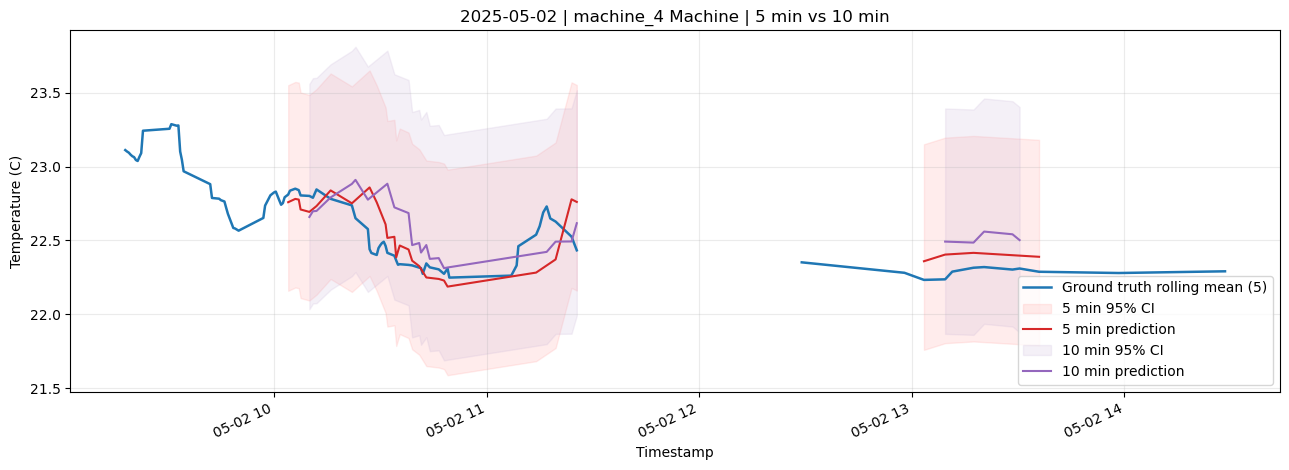

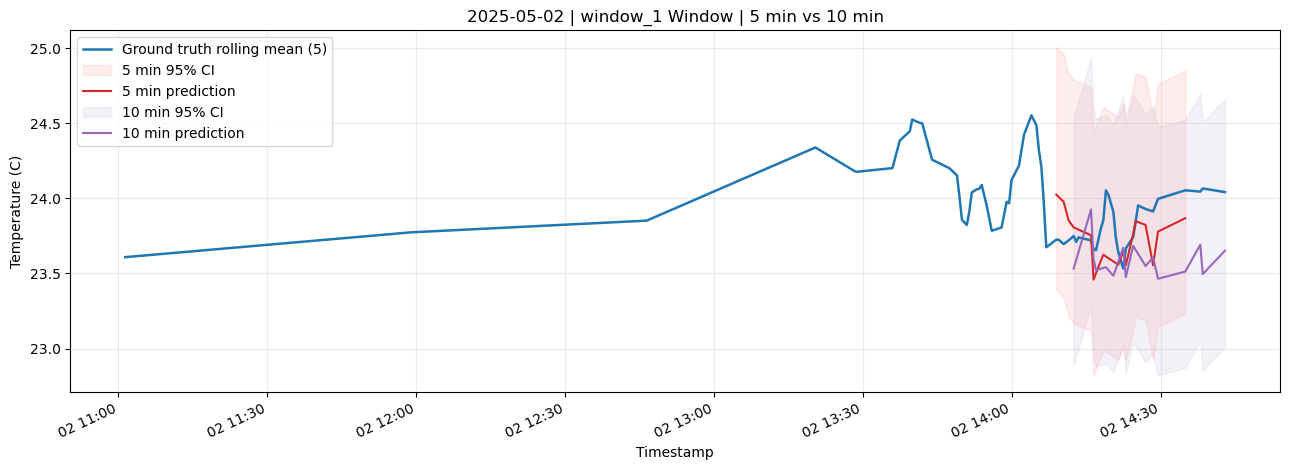

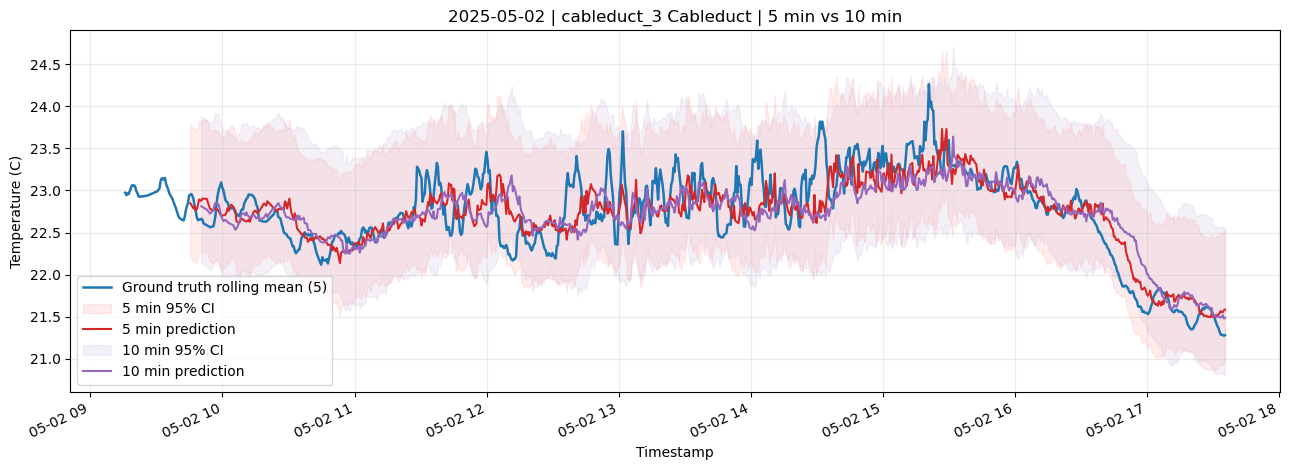

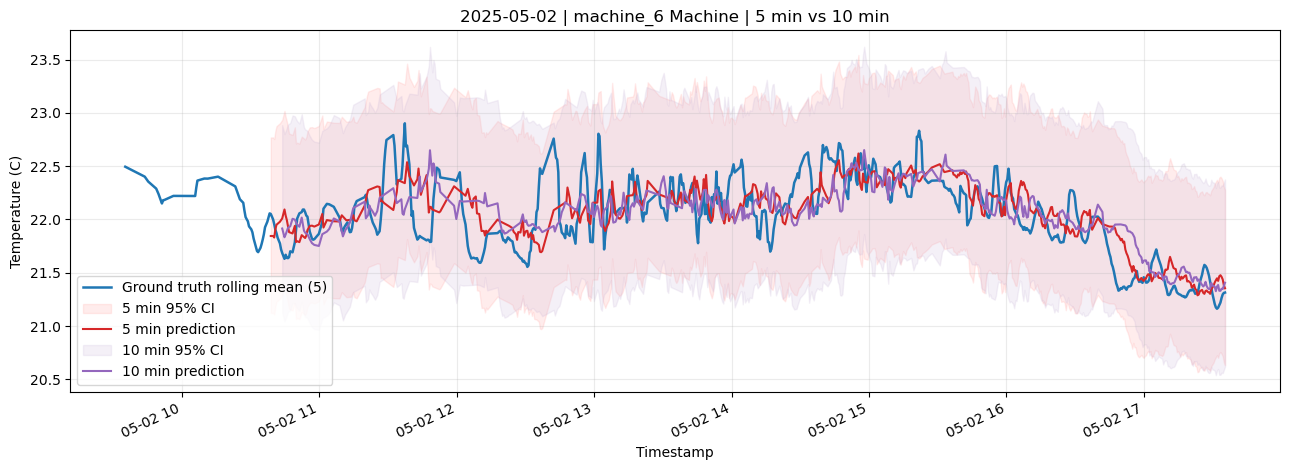

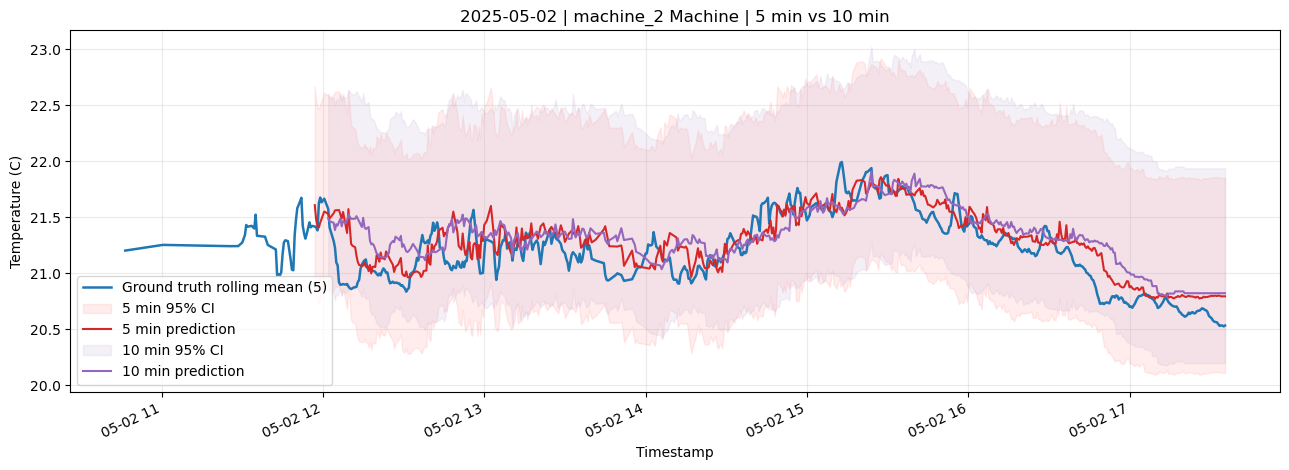

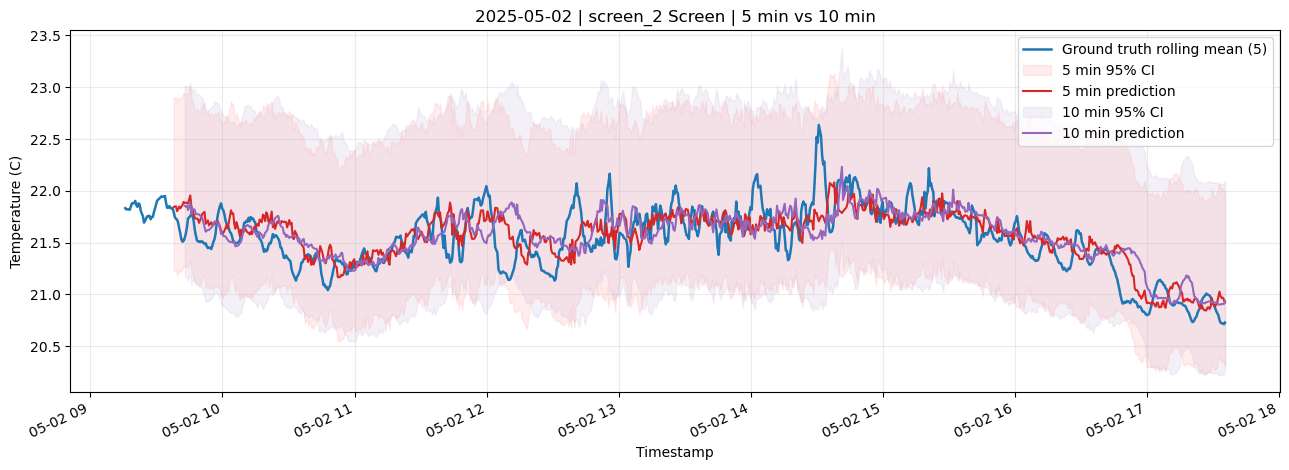

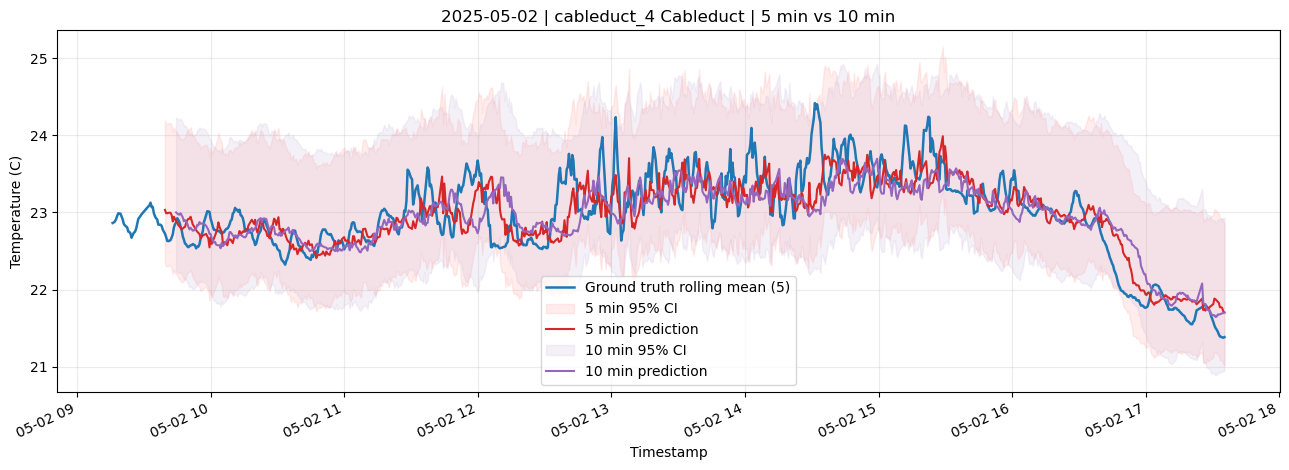

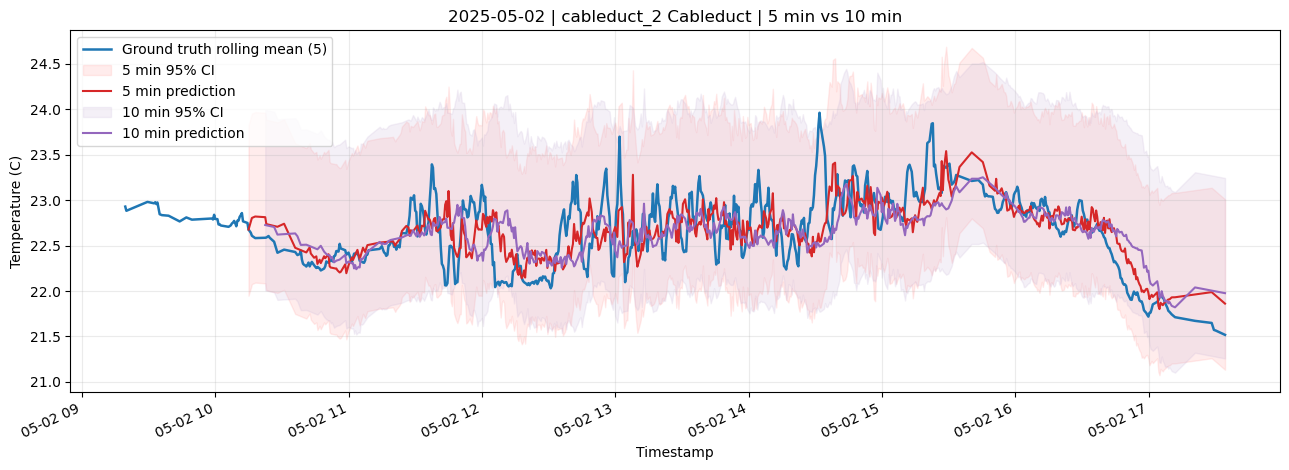

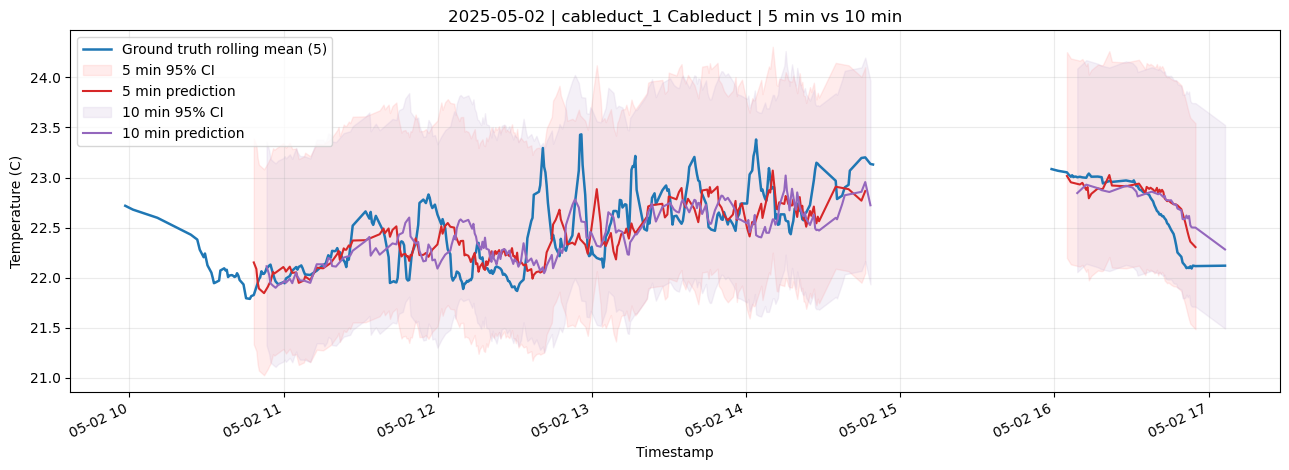

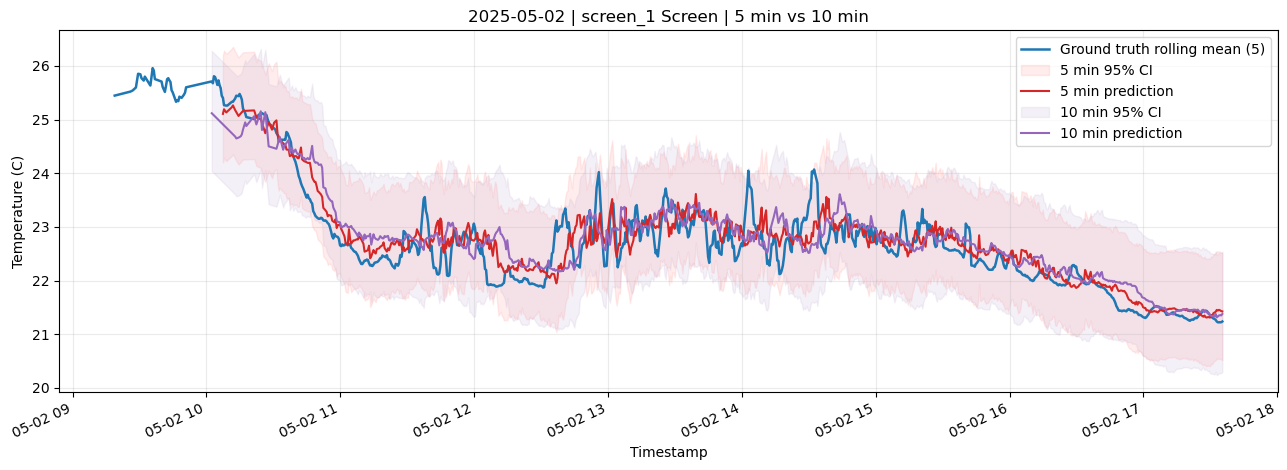

In [17]:
# empty list = plot objects with the narrowest average CI width across both horizons.
PLOT_OBJECT_IDS = []
N_OBJECTS_TO_PLOT = 15  # set none to plot all objects.
MAX_POINTS_PER_OBJECT = None  # set an integer if a plot is too dense.
MAX_LINE_GAP_MINUTES = 60.0  # break only across large missing-data gaps.
GT_SMOOTH_WINDOW = 5  # visual-only rolling mean window for ground truth.


# split plotted lines across large time gaps.
def add_plot_segments(df, time_col, value_cols, max_gap_minutes=2.0):
    df = df.sort_values(time_col).copy()
    gap = df[time_col].diff().dt.total_seconds().div(60)
    segment = gap.gt(max_gap_minutes).fillna(False).cumsum()
    return df.assign(_plot_segment=segment)


# apply visual-only rolling smoothing to ground truth values.
def smooth_ground_truth(df, value_col='ground_truth', window=5):
    df = df.sort_values('timestamp_dt').copy()
    if window is None or window <= 1 or df.empty:
        df['ground_truth_plot'] = df[value_col]
    else:
        df['ground_truth_plot'] = (
            df[value_col]
            .rolling(window=window, center=True, min_periods=1)
            .mean()
        )
    return df


# reduce plotted points while preserving the full time span.
def downsample_df(df, max_points):
    if max_points is None or len(df) <= max_points:
        return df
    keep_idx = np.linspace(0, len(df) - 1, max_points).astype(int)
    return df.iloc[keep_idx].copy()


# ground truth should come from the timeline, not from prediction rows.
timeline_gt = pd.read_csv(config.OBJECT_TIMELINE_CSV)
timeline_gt = timeline_gt[timeline_gt['people_or_machine'] == PEOPLE_OR_MACHINE].copy()
timeline_gt['timestamp_dt'] = pd.to_datetime(timeline_gt['timestamp'])
timeline_gt[TEMPERATURE_COLUMN] = pd.to_numeric(timeline_gt[TEMPERATURE_COLUMN], errors='coerce')
timeline_gt = timeline_gt.dropna(subset=['object_id', 'timestamp_dt', TEMPERATURE_COLUMN])
timeline_gt = (
    timeline_gt
    .groupby(['object_id', 'timestamp_dt'], as_index=False)
    .agg(
        canonical_label=('canonical_label', lambda s: s.mode().iloc[0] if not s.mode().empty else ''),
        ground_truth=(TEMPERATURE_COLUMN, 'mean'),
    )
)
timeline_gt['target_date'] = timeline_gt['timestamp_dt'].dt.date

# prediction rows can point to the same future target from multiple source timestamps.
# aggregate them before drawing one line/CI band per object, target time, and horizon.
plot_pred = test_pred.copy()
plot_pred['target_timestamp'] = pd.to_datetime(plot_pred['target_timestamp'])
plot_pred = (
    plot_pred
    .groupby(['object_id', 'canonical_label', 'target_minutes', 'target_timestamp'], as_index=False)
    .agg(
        prediction=('prediction', 'median'),
        ci_lower=('ci_lower', 'median'),
        ci_upper=('ci_upper', 'median'),
        prediction_rows=('prediction', 'size'),
    )
)
plot_pred['target_date'] = plot_pred['target_timestamp'].dt.date

print(f"GT plot rows from timeline: {len(timeline_gt):,}")
print(f"Prediction plot rows: {len(test_pred):,} -> {len(plot_pred):,} after target-time aggregation")

if PLOT_OBJECT_IDS:
    object_ids_to_plot = PLOT_OBJECT_IDS
else:
    object_ids_to_plot = confidence_pivot.mean(axis=1).sort_values().index.tolist()
    if N_OBJECTS_TO_PLOT is not None:
        object_ids_to_plot = object_ids_to_plot[:N_OBJECTS_TO_PLOT]

horizon_colors = {5.0: '#d62728', 10.0: '#9467bd'}
horizon_fill = {5.0: '#ff9896', 10.0: '#c5b0d5'}

available_dates = sorted(plot_pred['target_date'].unique())
for target_date in available_dates:
    print(f"Target date: {target_date}")
    for object_id in object_ids_to_plot:
        object_pred_day = plot_pred[(plot_pred['object_id'] == object_id) & (plot_pred['target_date'] == target_date)].copy()
        object_gt_day = timeline_gt[(timeline_gt['object_id'] == object_id) & (timeline_gt['target_date'] == target_date)].copy()
        object_gt_day = smooth_ground_truth(object_gt_day, window=GT_SMOOTH_WINDOW)
        if object_pred_day.empty and object_gt_day.empty:
            continue

        labels = []
        if not object_pred_day.empty:
            labels.extend(object_pred_day['canonical_label'].dropna().astype(str).tolist())
        if not object_gt_day.empty:
            labels.extend(object_gt_day['canonical_label'].dropna().astype(str).tolist())
        label = pd.Series(labels).mode().iloc[0] if labels else ''

        fig, ax = plt.subplots(figsize=(13, 4.8))

        gt_df = downsample_df(
            add_plot_segments(object_gt_day, 'timestamp_dt', ['ground_truth'], MAX_LINE_GAP_MINUTES),
            MAX_POINTS_PER_OBJECT,
        )
        for segment_id, segment in gt_df.groupby('_plot_segment'):
            ax.plot(
                segment['timestamp_dt'],
                segment['ground_truth_plot'],
                color='#1f77b4',
                linewidth=1.8,
                label=f'Ground truth rolling mean ({GT_SMOOTH_WINDOW})' if segment_id == gt_df['_plot_segment'].min() else None,
            )

        for target_minutes in TARGET_MINUTES_LIST:
            part = object_pred_day[object_pred_day['target_minutes'] == target_minutes].copy()
            if part.empty:
                continue
            part = downsample_df(
                add_plot_segments(part, 'target_timestamp', ['prediction', 'ci_lower', 'ci_upper'], MAX_LINE_GAP_MINUTES),
                MAX_POINTS_PER_OBJECT,
            )
            first_segment = part['_plot_segment'].min()
            for segment_id, segment in part.groupby('_plot_segment'):
                ax.fill_between(
                    segment['target_timestamp'],
                    segment['ci_lower'],
                    segment['ci_upper'],
                    color=horizon_fill.get(target_minutes, 'orange'),
                    alpha=0.18,
                    label=f'{target_minutes:g} min 95% CI' if segment_id == first_segment else None,
                )
                ax.plot(
                    segment['target_timestamp'],
                    segment['prediction'],
                    color=horizon_colors.get(target_minutes, '#333333'),
                    linewidth=1.5,
                    label=f'{target_minutes:g} min prediction' if segment_id == first_segment else None,
                )

        ax.set_title(f"{target_date} | {object_id} {label} | 5 min vs 10 min")
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Temperature (C)')
        ax.grid(alpha=0.25)
        ax.legend(loc='best')
        fig.autofmt_xdate(rotation=25)
        fig.tight_layout()






## Overall Error Distribution by Horizon


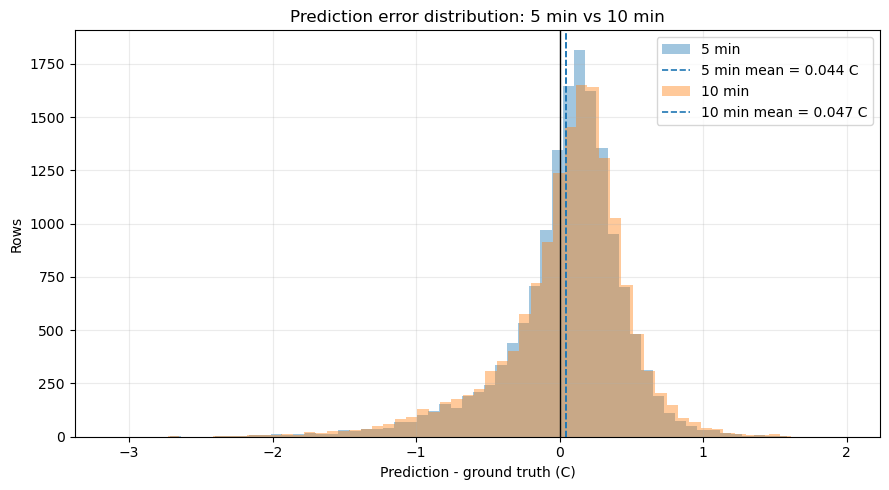

In [18]:
# create a diagnostic plot for the current result table.
fig, ax = plt.subplots(figsize=(9, 5))
for target_minutes in TARGET_MINUTES_LIST:
    part = test_pred[test_pred['target_minutes'] == target_minutes]
    ax.hist(part['error'], bins=60, alpha=0.42, label=f'{target_minutes:g} min')
    ax.axvline(part['error'].mean(), linestyle='--', linewidth=1.2, label=f'{target_minutes:g} min mean = {part["error"].mean():.3f} C')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Prediction error distribution: 5 min vs 10 min')
ax.set_xlabel('Prediction - ground truth (C)')
ax.set_ylabel('Rows')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()


## Error Distribution by Category


,canonical_label,target_minutes,rows,mean_error,median_error,mae,rmse,p05,p95
0,Cableduct,5.0,6411,0.022852,0.097502,0.325277,0.446473,-0.837851,0.584753
1,Cableduct,10.0,6394,0.013213,0.093301,0.344178,0.465866,-0.889952,0.621581
2,Chair,5.0,132,0.087803,0.187692,0.323413,0.435720,-0.616846,0.582770
3,Chair,10.0,133,0.131507,0.231065,0.335421,0.410527,-0.579954,0.566227
4,Machine,5.0,4487,0.053285,0.097622,0.266588,0.371986,-0.633788,0.526102
5,Machine,10.0,4458,0.068532,0.126152,0.295023,0.401756,-0.691343,0.565697
6,Screen,5.0,3676,0.077625,0.137579,0.322159,0.447339,-0.782334,0.659602
7,Screen,10.0,3642,0.095269,0.155965,0.361306,0.497982,-0.866067,0.750718
8,Window,5.0,644,-0.013991,0.025314,0.305200,0.404068,-0.711138,0.552041
9,Window,10.0,648,-0.046127,0.011386,0.360357,0.455433,-0.868082,0.597640


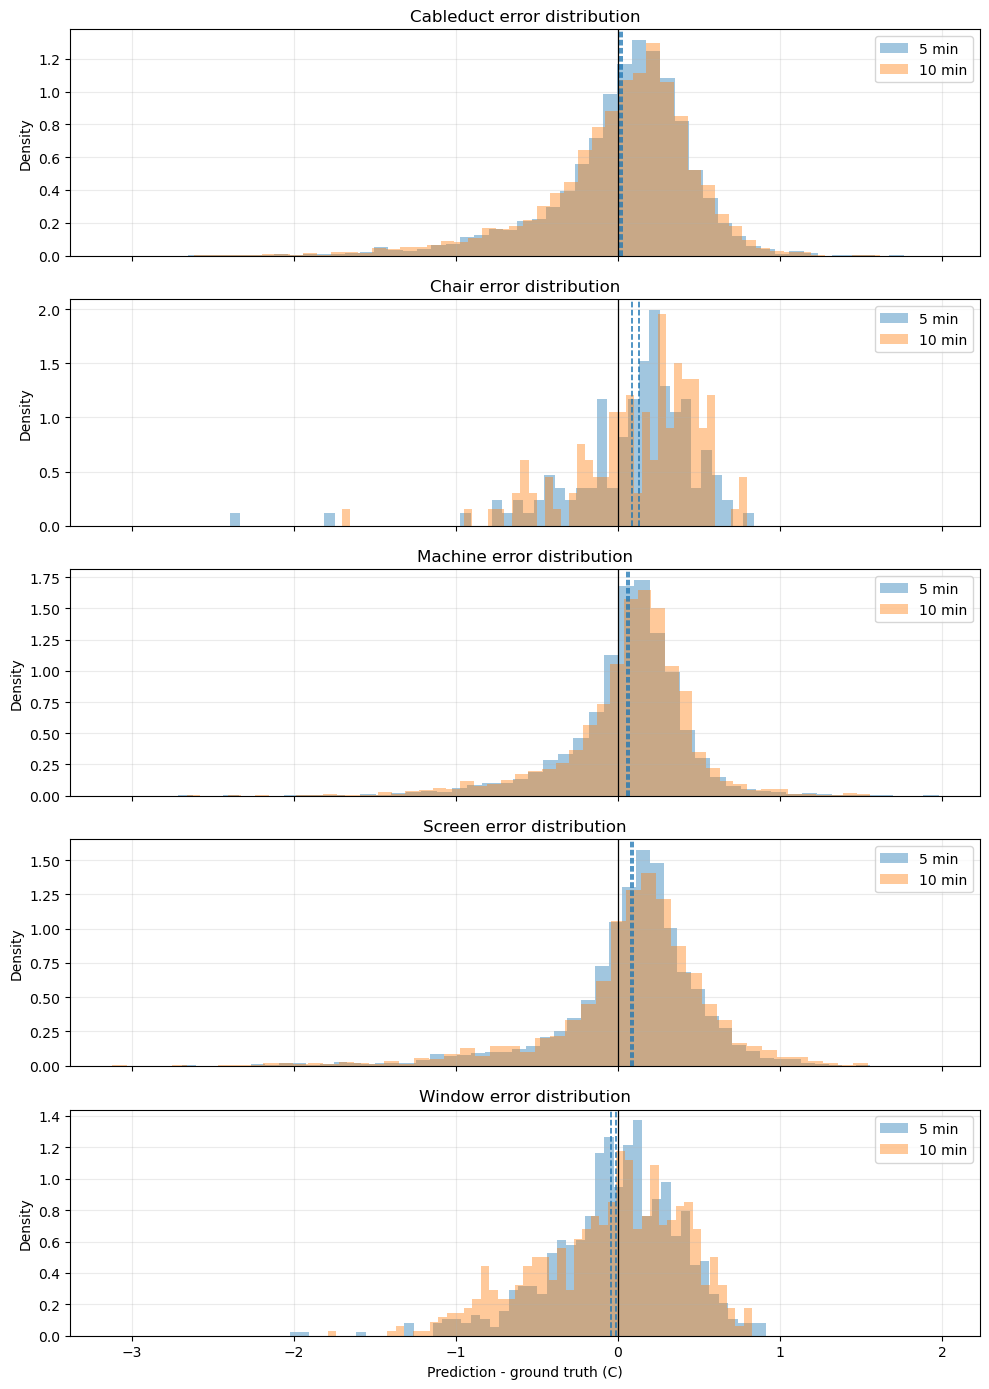

In [19]:
# define reusable error summaries for grouped diagnostics.
def error_summary_table(df, group_cols):
    rows = []
    for keys, part in df.groupby(group_cols, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        error = part['error'].dropna()
        if error.empty:
            continue
        row = dict(zip(group_cols, keys))
        row.update({
            'rows': len(error),
            'mean_error': error.mean(),
            'median_error': error.median(),
            'mae': error.abs().mean(),
            'rmse': np.sqrt((error ** 2).mean()),
            'p05': error.quantile(0.05),
            'p95': error.quantile(0.95),
        })
        rows.append(row)
    return pd.DataFrame(rows)


category_error_summary = error_summary_table(test_pred, ['canonical_label', 'target_minutes'])
display(category_error_summary.sort_values(['canonical_label', 'target_minutes']))

category_labels = sorted(test_pred['canonical_label'].dropna().unique())
fig, axes = plt.subplots(
    len(category_labels),
    1,
    figsize=(10, max(3.2, 2.8 * len(category_labels))),
    sharex=True,
)
if len(category_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, category_labels):
    for target_minutes in TARGET_MINUTES_LIST:
        part = test_pred[
            (test_pred['canonical_label'] == label) &
            (test_pred['target_minutes'] == target_minutes)
        ]['error'].dropna()
        if part.empty:
            continue
        ax.hist(part, bins=50, alpha=0.42, density=True, label=f'{target_minutes:g} min')
        ax.axvline(part.mean(), linestyle='--', linewidth=1.1)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_title(f'{label} error distribution')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

axes[-1].set_xlabel('Prediction - ground truth (C)')
fig.tight_layout()


## Error Distribution by Object


,object_id,canonical_label,target_minutes,rows,mean_error,median_error,mae,rmse,p05,p95
0,cableduct_1,Cableduct,5.0,1236,0.028251,0.114075,0.346499,0.482102,-0.933848,0.599780
1,cableduct_1,Cableduct,10.0,1235,0.012251,0.113420,0.366349,0.493203,-1.003566,0.633790
2,cableduct_2,Cableduct,5.0,1582,0.034552,0.116572,0.338676,0.459527,-0.889430,0.627473
3,cableduct_2,Cableduct,10.0,1589,0.022874,0.111189,0.352516,0.477928,-0.927847,0.609375
4,cableduct_3,Cableduct,5.0,1762,0.022439,0.084456,0.291539,0.394325,-0.740678,0.547964
5,cableduct_3,Cableduct,10.0,1754,0.014249,0.084893,0.318659,0.422216,-0.807987,0.572277
6,cableduct_4,Cableduct,5.0,1831,0.009497,0.086214,0.331842,0.457145,-0.830126,0.591252
7,cableduct_4,Cableduct,10.0,1816,0.004412,0.069148,0.346453,0.476110,-0.841434,0.647050
8,chair_1,Chair,5.0,132,0.087803,0.187692,0.323413,0.435720,-0.616846,0.582770
9,chair_1,Chair,10.0,133,0.131507,0.231065,0.335421,0.410527,-0.579954,0.566227


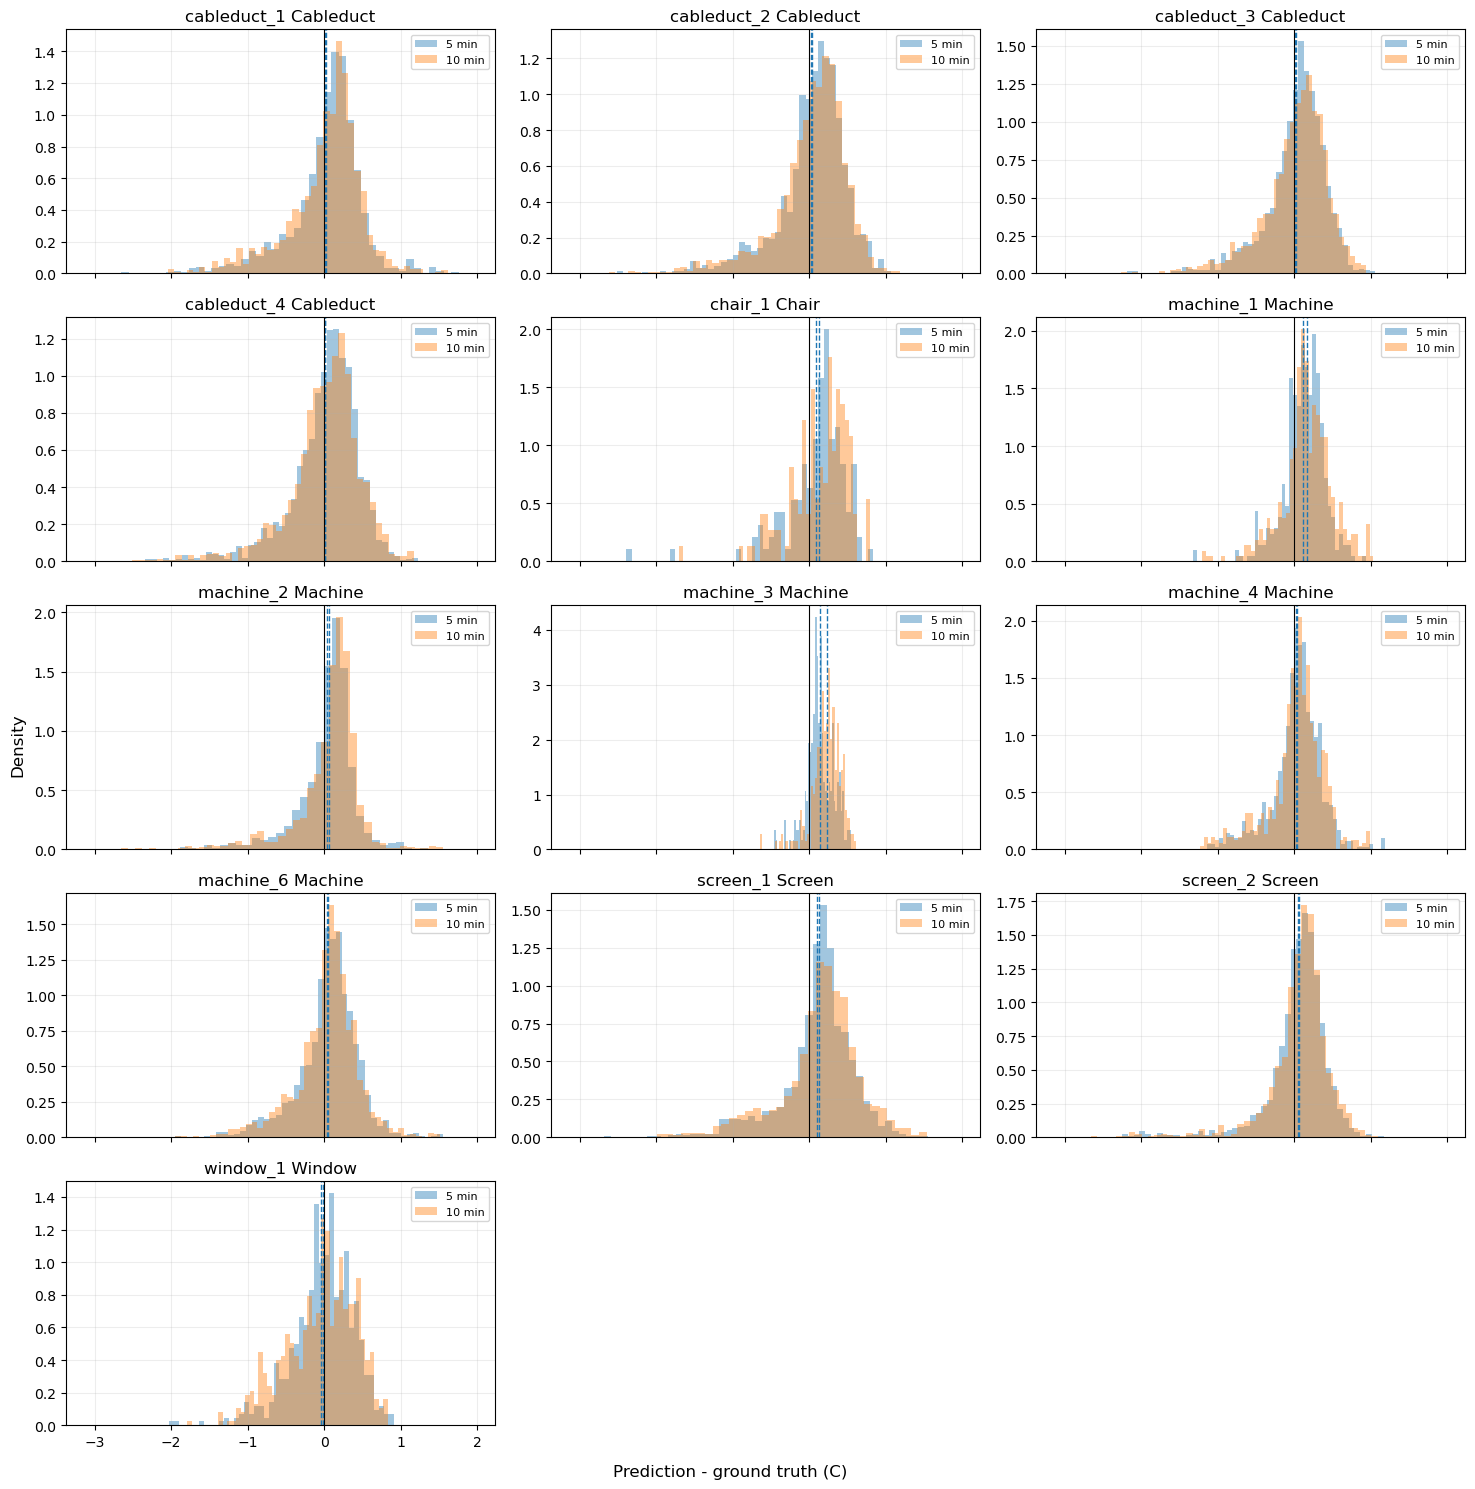

In [20]:
# configure object-level error distribution plots.
OBJECT_ERROR_IDS = []  # empty list = all objects in test_pred.
OBJECT_ERROR_MAX_OBJECTS = None  # set an integer if the grid is too large.
OBJECT_ERROR_BINS = 45

object_error_summary = error_summary_table(test_pred, ['object_id', 'canonical_label', 'target_minutes'])
display(object_error_summary.sort_values(['canonical_label', 'object_id', 'target_minutes']))

if OBJECT_ERROR_IDS:
    object_ids_for_error = OBJECT_ERROR_IDS
else:
    object_order = (
        test_pred[['object_id', 'canonical_label']]
        .drop_duplicates()
        .sort_values(['canonical_label', 'object_id'])
    )
    object_ids_for_error = object_order['object_id'].tolist()
    if OBJECT_ERROR_MAX_OBJECTS is not None:
        object_ids_for_error = object_ids_for_error[:OBJECT_ERROR_MAX_OBJECTS]

n_objects = len(object_ids_for_error)
ncols = 3
nrows = int(np.ceil(n_objects / ncols)) if n_objects else 1
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, max(3.2, 3.0 * nrows)),
    sharex=True,
    sharey=False,
)
axes = np.atleast_1d(axes).ravel()

for ax, object_id in zip(axes, object_ids_for_error):
    object_rows = test_pred[test_pred['object_id'] == object_id]
    label = object_rows['canonical_label'].mode().iloc[0] if not object_rows['canonical_label'].mode().empty else ''
    for target_minutes in TARGET_MINUTES_LIST:
        part = object_rows[object_rows['target_minutes'] == target_minutes]['error'].dropna()
        if part.empty:
            continue
        ax.hist(part, bins=OBJECT_ERROR_BINS, alpha=0.42, density=True, label=f'{target_minutes:g} min')
        ax.axvline(part.mean(), linestyle='--', linewidth=1.0)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{object_id} {label}')
    ax.grid(alpha=0.22)
    ax.legend(loc='best', fontsize=8)

for ax in axes[n_objects:]:
    ax.axis('off')

fig.supxlabel('Prediction - ground truth (C)')
fig.supylabel('Density')
fig.tight_layout()


## Daily Test Forecast GIFs by Horizon


In [21]:
# train and evaluate LGBM temperature prediction.
'''
# forecast view GIFs. empty list means machines are selected by row count in the selected test split.
GIF_MACHINE_IDS = []
MAX_MACHINES_TO_SHOW = 4  # set an integer like 4, 8, or 16. none means all machines.
MACHINES_PER_GIF = 2  # use 1 or 2. selected machines will be split across multiple GIFs.
MAX_GIF_FRAMES = 120
GIF_FPS = 6

gif_paths_by_horizon = {}
for target_minutes, args in lgbm_args_by_horizon.items():
    gif_paths_by_horizon[target_minutes] = build_daily_prediction_gifs(
        predictions_csv=args.prediction_csv,
        output_dir=args.prediction_csv.parent / 'prediction_gifs',
        split='test',
        machine_ids=GIF_MACHINE_IDS,
        max_machines=MAX_MACHINES_TO_SHOW,
        machines_per_gif=MACHINES_PER_GIF,
        max_frames=MAX_GIF_FRAMES,
        fps=GIF_FPS,
    )

{horizon_tag(target_minutes): paths for target_minutes, paths in gif_paths_by_horizon.items()}
'''

"\n# Forecast view GIFs. Empty list means machines are selected by row count in the selected test split.\nGIF_MACHINE_IDS = []\nMAX_MACHINES_TO_SHOW = 4  # Set an integer like 4, 8, or 16. None means all machines.\nMACHINES_PER_GIF = 2  # Use 1 or 2. Selected machines will be split across multiple GIFs.\nMAX_GIF_FRAMES = 120\nGIF_FPS = 6\n\ngif_paths_by_horizon = {}\nfor target_minutes, args in lgbm_args_by_horizon.items():\n    gif_paths_by_horizon[target_minutes] = build_daily_prediction_gifs(\n        predictions_csv=args.prediction_csv,\n        output_dir=args.prediction_csv.parent / 'prediction_gifs',\n        split='test',\n        machine_ids=GIF_MACHINE_IDS,\n        max_machines=MAX_MACHINES_TO_SHOW,\n        machines_per_gif=MACHINES_PER_GIF,\n        max_frames=MAX_GIF_FRAMES,\n        fps=GIF_FPS,\n    )\n\n{horizon_tag(target_minutes): paths for target_minutes, paths in gif_paths_by_horizon.items()}\n"

In [22]:
# for target_minutes, gif_paths in gif_paths_by_horizon.items():
#     print(f'{target_minutes:g} minute GIFs')
#     for gif_path in gif_paths:
#         print(gif_path.name)
#         display(Image(filename=str(gif_path)))


## Test Predictions Preview


In [23]:
# train and evaluate LGBM temperature prediction.
preview_predictions = []
for target_minutes, horizon_result in results_by_horizon.items():
    part = horizon_result['predictions'].query("split == 'test'").head(10).copy()
    part.insert(0, 'target_minutes', target_minutes)
    preview_predictions.append(part)

pd.concat(preview_predictions, ignore_index=True)


,target_minutes,object_id,timestamp,target_timestamp,canonical_label,display_x,display_y,source_temp,target_minutes_ahead,people_count_total,...,people_count_within_2m,people_count_within_3m,nearest_person_distance,mean_person_distance,nearest_person_dx,nearest_person_dy,target_temp,split,prediction,error
0,5.0,cableduct_1,2025-04-24 07:01:17,2025-04-24 07:06:18,Cableduct,11.689842,3.324211,20.722349,5.016667,1,...,0,0,7.758399,7.758399,7.52557,1.886414,20.768026,test,20.844648,0.076622
1,5.0,cableduct_1,2025-04-24 07:01:48,2025-04-24 07:07:18,Cableduct,11.689842,3.324211,20.758368,5.500000,0,...,0,0,NaN,NaN,NaN,NaN,20.736496,test,20.868491,0.131995
2,5.0,cableduct_1,2025-04-24 07:02:18,2025-04-24 07:07:18,Cableduct,11.689842,3.324211,20.678381,5.000000,0,...,0,0,NaN,NaN,NaN,NaN,20.736496,test,20.829694,0.093198
3,5.0,cableduct_1,2025-04-24 07:02:48,2025-04-24 07:07:48,Cableduct,11.689842,3.324211,20.700623,5.000000,0,...,0,0,NaN,NaN,NaN,NaN,20.703457,test,20.835644,0.132187
4,5.0,cableduct_1,2025-04-24 07:03:18,2025-04-24 07:08:48,Cableduct,11.689842,3.324211,20.774504,5.500000,0,...,0,0,NaN,NaN,NaN,NaN,20.703279,test,20.899460,0.196181
5,5.0,cableduct_1,2025-04-24 07:03:48,2025-04-24 07:08:48,Cableduct,11.689842,3.324211,20.743622,5.000000,0,...,0,0,NaN,NaN,NaN,NaN,20.703279,test,20.845468,0.142189
6,5.0,cableduct_1,2025-04-24 07:04:17,2025-04-24 07:09:18,Cableduct,11.689842,3.324211,20.796827,5.016667,0,...,0,0,NaN,NaN,NaN,NaN,20.656719,test,20.846676,0.189957
7,5.0,cableduct_1,2025-04-24 07:04:48,2025-04-24 07:09:48,Cableduct,11.689842,3.324211,20.749052,5.000000,0,...,0,0,NaN,NaN,NaN,NaN,20.758543,test,20.847563,0.089020
8,5.0,cableduct_1,2025-04-24 07:05:17,2025-04-24 07:10:18,Cableduct,11.689842,3.324211,20.743179,5.016667,0,...,0,0,NaN,NaN,NaN,NaN,20.672283,test,20.855137,0.182854
9,5.0,cableduct_1,2025-04-24 07:05:48,2025-04-24 07:10:48,Cableduct,11.689842,3.324211,20.623709,5.000000,0,...,0,0,NaN,NaN,NaN,NaN,20.647320,test,20.855557,0.208237
